# Music Recommender — End-to-End Pipeline
Complete pipeline: dataset extraction → user data → symbolic music features → KG construction & enrichment → baselines → autoencoder → HGT recommender.  


Every major section checks for cached artefacts on disk before re-running expensive steps. Set `FORCE_REBUILD = True` to invalidate all caches.

## 0 — Environment Setup (Colab vs. Local)

| | Local (VSCode) | Google Colab |
|---|---|---|
| **Code** (`src/`) | This repo, on disk | Cloned from GitHub |
| **Data** (`data/`) | `<repo>/data/` | Google Drive |
| **API keys** | `<repo>/.env` | Colab Secrets or Drive `.env` |

### `.env` on Colab
The kernel runs on Google's servers — place `.env` in Drive. Bootstrap probes (in order):
1. Colab Secret `dotenv_path`
2. `/content/drive/MyDrive/.env`
3. `<gdrive_proj_path>/.env`

### Configuration keys

| Key | Purpose | Default |
|---|---|---|
| `gdrive_proj_path` | Drive project folder | `/content/drive/MyDrive/DL-KG-project` |
| `repo_branch` | Branch to clone/pull | `main` |
| `WANDB_API_KEY` | W&B logging | (skipped) |
| `jSymbolic2_path` | Path to `jSymbolic2.jar` | `<repo>/jSymbolic/jSymbolic2.jar` |
| `dotenv_path` | Explicit Drive `.env` path | (none) |

### One-time Colab setup
Upload `data/` and `jSymbolic/jSymbolic2.jar` to `<gdrive_proj_path>/` in Drive.


In [ ]:
import h5py
import logging
import sys, warnings, re, json, subprocess, importlib, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import music21
import gc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

try:
    import google.colab
    ON_COLAB = True
    USE_GRAPHDB = False
except ImportError:
    ON_COLAB = False
    USE_GRAPHDB = True

print(f"Runtime: {'Google Colab' if ON_COLAB else 'Local'}")

if ON_COLAB:
    from google.colab import drive
    _s, _e = sys.stdout, sys.stderr
    drive.mount("/content/drive")
    sys.stdout, sys.stderr = _s, _e

    try:
        from google.colab import userdata as _ud
        _branch = _ud.get("repo_branch")
    except Exception:
        _branch = "main"

    _REPO = Path("/content/DL-KG-project")
    _URL  = "https://github.com/aarthip97/DL-KG-project.git"
    if not _REPO.exists():
        subprocess.run(["git", "clone", "--branch", _branch, _URL, str(_REPO)], check=True)
        print(f"Cloned  {_branch} -> {_REPO}")
    else:
        subprocess.run(["git", "-C", str(_REPO), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(_REPO), "checkout", _branch], check=True)
        subprocess.run(["git", "-C", str(_REPO), "pull", "--ff-only", "origin", _branch], check=True)
        print(f"Updated {_branch} -> {_REPO}")
        # Invalidate Python's module finder cache so newly pulled .py files are
        # immediately discoverable in the current kernel session.
        importlib.invalidate_caches()

    ROOT = _REPO
    # Upgrade IPython before installing requirements: older Colab IPython builds
    # still import the `imp` module (removed in Python 3.12), which breaks the
    # autoreload extension with ModuleNotFoundError('imp').
    subprocess.run(["pip", "install", "-q", "--upgrade", "ipython"], check=True)
    print("IPython upgraded.")
    subprocess.run(["pip", "install", "-q", "-r", str(ROOT / "requirements.txt")], check=True)
    print("Requirements installed.")

# ── Local: ROOT is one level above notebooks/ ─────────────────────────────────
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# ── Make src/ importable, then run full environment setup ────────────────────
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

Runtime: Local


In [2]:
try:
    %reload_ext autoreload
    %autoreload 2
except Exception as _e:
    print(f"[WARN] autoreload unavailable: {_e}")

from nb_env import setup
globals().update(setup(ROOT, ON_COLAB))

FORCE_REBUILD = False
SKIP_DOWNLOAD = True


  [.env] found
  root       : DL-KG-project/
  data/      : data/
  models/    : models/
  jSymbolic  : jSymbolic/jSymbolic2.jar  (✓ found)
  device     : cpu
  USE_GRAPHDB: True


## 1 — Lakh MIDI and Million Song Dataset Extraction
Links Lakh MIDI files to Million Song Dataset tracks, keeps matches with DTW score ≥ 0.55, reads MSD HDF5 metadata, extracts MIDI instrumentation and other useful fields, deduplicates records, and saves the result to `data/processed/lakh_msd_dataset.parquet`.

>**Note**: the HDF5 metadata/songs genre field was empty in this dump and many analysis arrays are multidimensional/unused, so those were omitted. Several attributes are derived directly from the MIDI files instead of from those HDF5 arrays.

In [3]:
H5_ROOT = RAW / "lmd_matched_h5"
# Safely get the first .h5 file (returns None if no match)
sample = next(H5_ROOT.rglob('*.h5'), None)

if sample is None:
    raise FileNotFoundError(f"No .h5 files found under {H5_ROOT!s}. "
                            "Ensure the data are downloaded and the path is correct.")

def print_h5_structure(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Dataset):
        print(f"{indent} {name}: shape={obj.shape}  dtype={obj.dtype}")
        # Print first value for compound/string datasets
        if getattr(obj, "shape", None) and getattr(obj.dtype, "names", None):
            list_fields = list(obj.dtype.names)
            if len(list_fields) > 5:
                lines = [list_fields[i:i+5] for i in range(0, len(list_fields), 5)]
                for line in lines:
                    print(f"{indent}   fields: {line}")
            else:
                print(f"{indent}   fields: {list_fields}")
    else:
        print(f"{indent} {name}/")

print(f"File: {sample.relative_to(ROOT)}\n")
with h5py.File(sample, 'r') as f:
    f.visititems(print_h5_structure)

File: data/raw/lmd_matched_h5/L/L/S/TRLLSTQ128F1490A26.h5

 analysis/
   analysis/bars_confidence: shape=(73,)  dtype=float64
   analysis/bars_start: shape=(73,)  dtype=float64
   analysis/beats_confidence: shape=(296,)  dtype=float64
   analysis/beats_start: shape=(296,)  dtype=float64
   analysis/sections_confidence: shape=(10,)  dtype=float64
   analysis/sections_start: shape=(10,)  dtype=float64
   analysis/segments_confidence: shape=(432,)  dtype=float64
   analysis/segments_loudness_max: shape=(432,)  dtype=float64
   analysis/segments_loudness_max_time: shape=(432,)  dtype=float64
   analysis/segments_loudness_start: shape=(432,)  dtype=float64
   analysis/segments_pitches: shape=(432, 12)  dtype=float64
   analysis/segments_start: shape=(432,)  dtype=float64
   analysis/segments_timbre: shape=(432, 12)  dtype=float64
   analysis/songs: shape=(1,)  dtype=[('analysis_sample_rate', '<i4'), ('audio_md5', 'S32'), ('danceability', '<f8'), ('duration', '<f8'), ('end_of_fade_in', '<f8'

In [4]:
from data.dataset_extraction import LakhMSDLinker, load_dataset

_manifest = json.loads((RAW / "manifest.json").read_text()) if (RAW / "manifest.json").exists() else {}
MIDI_ROOT         = Path(_manifest.get("lmd_matched",    {}).get("unpacked", RAW / "lmd_matched"))
H5_ROOT           = Path(_manifest.get("lmd_matched_h5", {}).get("unpacked", RAW / "lmd_matched_h5"))
MATCH_SCORES_PATH = Path(_manifest.get("match_scores",   {}).get("archive",  RAW / "match_scores.json"))

if not SKIP_DOWNLOAD:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "download_lmd.py"),
                    "--dest", str(RAW), "--skip-existing"], check=True)

if LAKH_PQ.exists() and not FORCE_REBUILD:
    lakh_df = load_dataset(LAKH_PQ)
    print(f"[SKIP] lakh_msd: {lakh_df.shape}")
else:
    linker  = LakhMSDLinker(midi_root=MIDI_ROOT, h5_root=H5_ROOT,
                            match_scores_path=MATCH_SCORES_PATH,
                            min_score=0.55, pick_midi="best")
    lakh_df = linker.build_dataset(max_tracks=None, verbose=True, include_midi=True)
    lakh_df.to_parquet(LAKH_PQ, index=False)
    print(f"saved → {LAKH_PQ.relative_to(ROOT)}  shape={lakh_df.shape}")

print(f"Dataset: {len(lakh_df):,} tracks, {lakh_df.shape[1]} cols")


[SKIP] lakh_msd: (19037, 40)
Dataset: 19,037 tracks, 40 cols


### 1.1. Exploratory Data Analysis on Music Datasets
Lakh MIDI / Million Song overview: match-score distribution, track counts by decade, and MIDI instrumentation breakdown.

=== null summary ===


,null_count,null_pct
artist_longitude,12518,65.76
artist_latitude,12518,65.76
artist_mbtags,9895,51.98
artist_mbtags_count,9895,51.98
song_hotttnesss,8890,46.70
year,8603,45.19
artist_location,8041,42.24
artist_mbid,1150,6.04
top3_genres,212,1.11
artist_terms,212,1.11



=== dtypes ===


,count
dtype,
float64,16
str,13
object,8
int64,3



=== numeric summary ===


,match_score,tempo,artist_familiarity,artist_hotttnesss,song_hotttnesss,duration,loudness,danceability,energy,key_confidence,mode_confidence,time_signature,time_signature_confidence
count,19037.000,19037.000,19035.000,19037.000,10147.000,19037.000,19037.000,19037.0,19037.0,19037.000,19037.000,19037.000,19037.000
mean,0.713,120.158,0.596,0.424,0.429,248.111,-10.574,0.0,0.0,0.500,0.529,3.605,0.497
std,0.059,31.699,0.163,0.143,0.263,100.290,5.442,0.0,0.0,0.279,0.194,1.136,0.368
min,0.550,0.000,0.000,0.000,0.000,0.626,-43.136,0.0,0.0,0.000,0.000,0.000,0.000
25%,0.685,98.301,0.499,0.355,0.254,191.791,-12.906,0.0,0.0,0.295,0.414,4.000,0.107
50%,0.728,120.484,0.600,0.415,0.451,233.038,-9.300,0.0,0.0,0.528,0.542,4.000,0.524
75%,0.745,136.974,0.708,0.509,0.633,283.742,-6.794,0.0,0.0,0.708,0.662,4.000,0.841
max,1.276,262.183,1.000,1.083,1.000,2149.329,-0.205,0.0,0.0,1.000,1.000,7.000,1.000


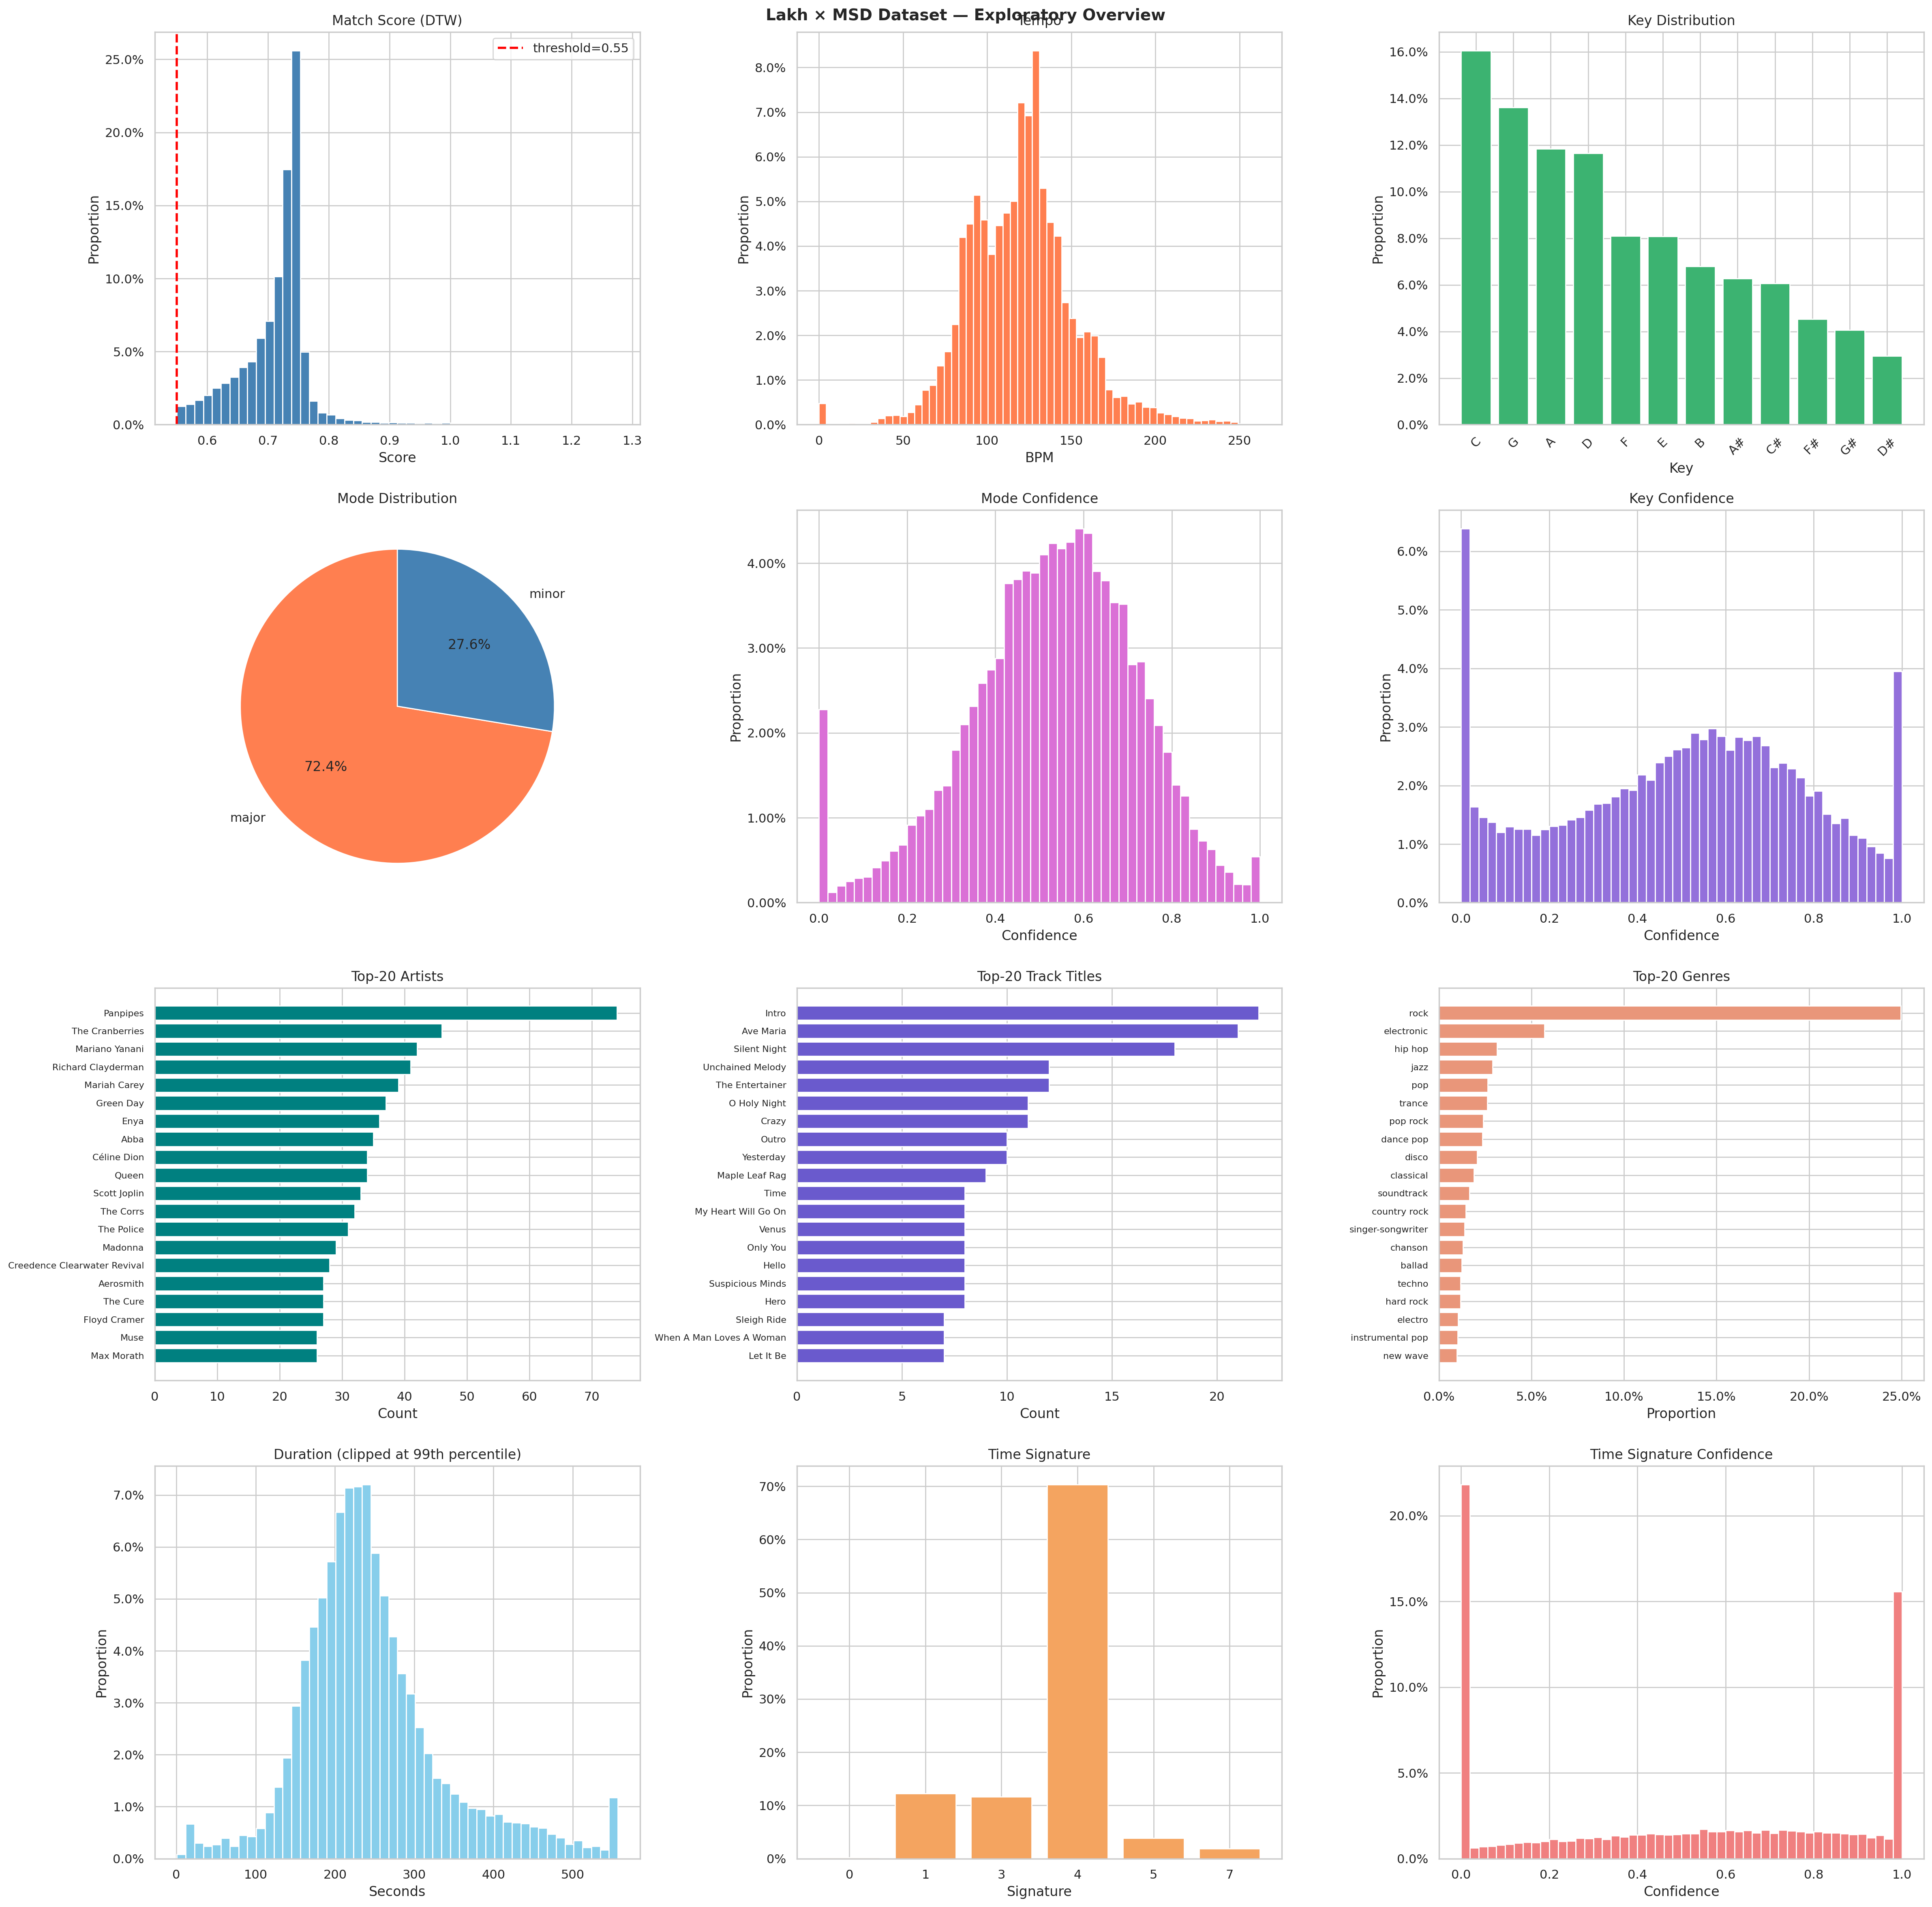

,value
metric,
# tracks parsed,"18,859 (99.1% of dataset)"
mean # instrument tracks / file,10.08
median # instrument tracks / file,10
% files containing drums,85.2%
# unique instrument names seen,129


63973

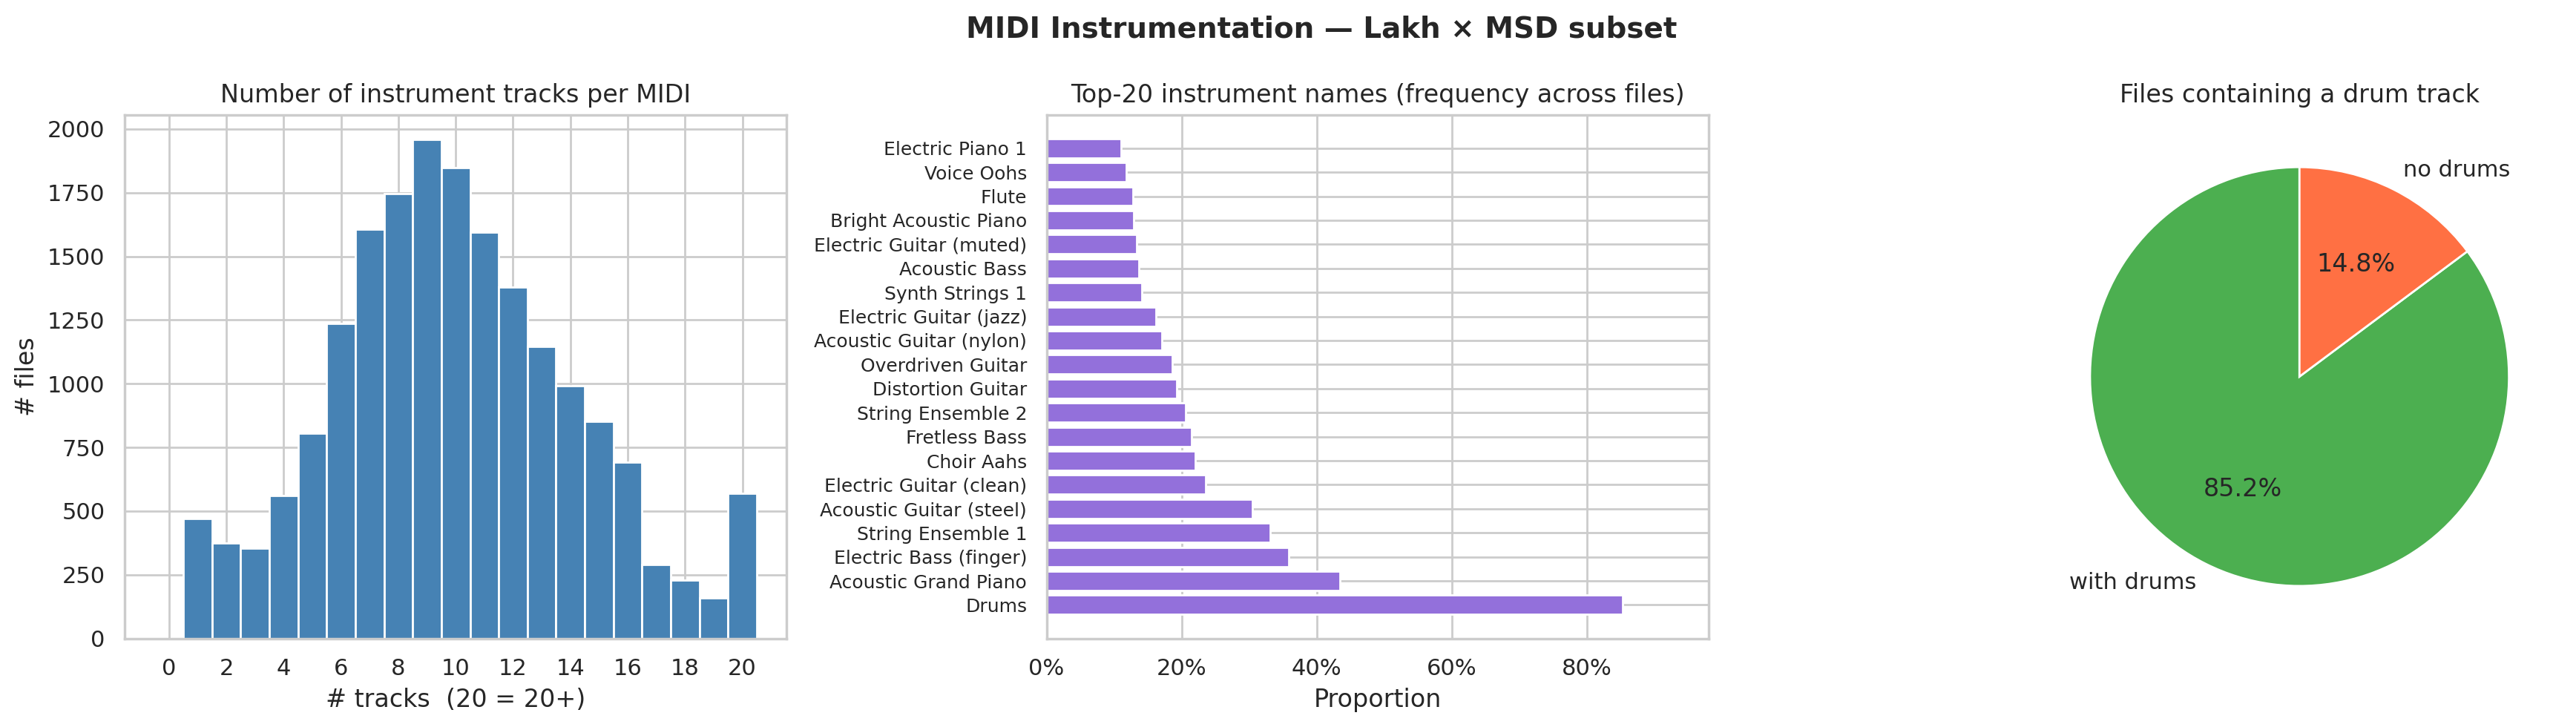

In [5]:
from data.eda import plot_lakh_overview, plot_midi_instrumentation

plot_lakh_overview(lakh_df, min_score=0.55)
plot_midi_instrumentation(lakh_df, show=False)

gc.collect()

## 2. User Data Integration
Downloads Echo Nest Taste Profile (train_triplets.txt), removes mismatch songs, intersects with LMD, cold-start filters (≥ 5 plays/user), saves filtered parquet.

In [6]:
from data.dataset_extraction import (
    load_taste_profile, load_sid_mismatches,
    filter_taste_profile, build_user_song_stats,
)

TRIPLETS_TXT = RAW / "train_triplets.txt"
MISMATCHES   = RAW / "sid_mismatches.txt"

if not SKIP_DOWNLOAD:
    for target in ("triplets", "mismatches"):
        subprocess.run([sys.executable, str(ROOT / "scripts" / "download_user_data.py"),
                        "--dest", str(RAW), "--only", target], check=True)

if TASTE_PQ.exists() and PER_USER_CSV.exists() and PER_SONG_CSV.exists() and not FORCE_REBUILD:
    taste_df = pd.read_parquet(TASTE_PQ)
    print(f"[SKIP] taste_profile: {taste_df.shape}")
else:
    raw_triplets = load_taste_profile(TRIPLETS_TXT, chunksize=500_000, verbose=True)
    bad_song_ids = load_sid_mismatches(MISMATCHES, verbose=True)
    lmd_song_ids = set(lakh_df["song_id"].dropna().unique())
    taste_df = filter_taste_profile(raw_triplets, bad_song_ids=bad_song_ids,
                                    lmd_song_ids=lmd_song_ids, min_plays_per_user=5, verbose=True)
    stats_d  = build_user_song_stats(taste_df, lmd_df=lakh_df)
    taste_df.to_parquet(TASTE_PQ, index=False)
    stats_d["per_user"].reset_index().to_csv(PER_USER_CSV, index=False)
    stats_d["per_song"].reset_index().to_csv(PER_SONG_CSV, index=False)
    print(f"saved → {TASTE_PQ}  shape={taste_df.shape}")

print(f"Taste profile: {len(taste_df):,} interactions  "
      f"users={taste_df['user_id'].nunique():,}  songs={taste_df['song_id'].nunique():,}")

[SKIP] taste_profile: (3048959, 3)
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227


### 2.1. Exploratory Data Analysis on User Data
Echo Nest Taste Profile: funnel (raw → deduped → filtered) and per-user / per-song play-count diagnostics.

             Interactions  Unique Users  Unique Songs
Step                                                 
Raw              48373586       1019318        384546
−Mismatches      45795100       1019318        378309
∩ LMD             4243384        848243          7465
−Cold-start       3048959        299156          7227


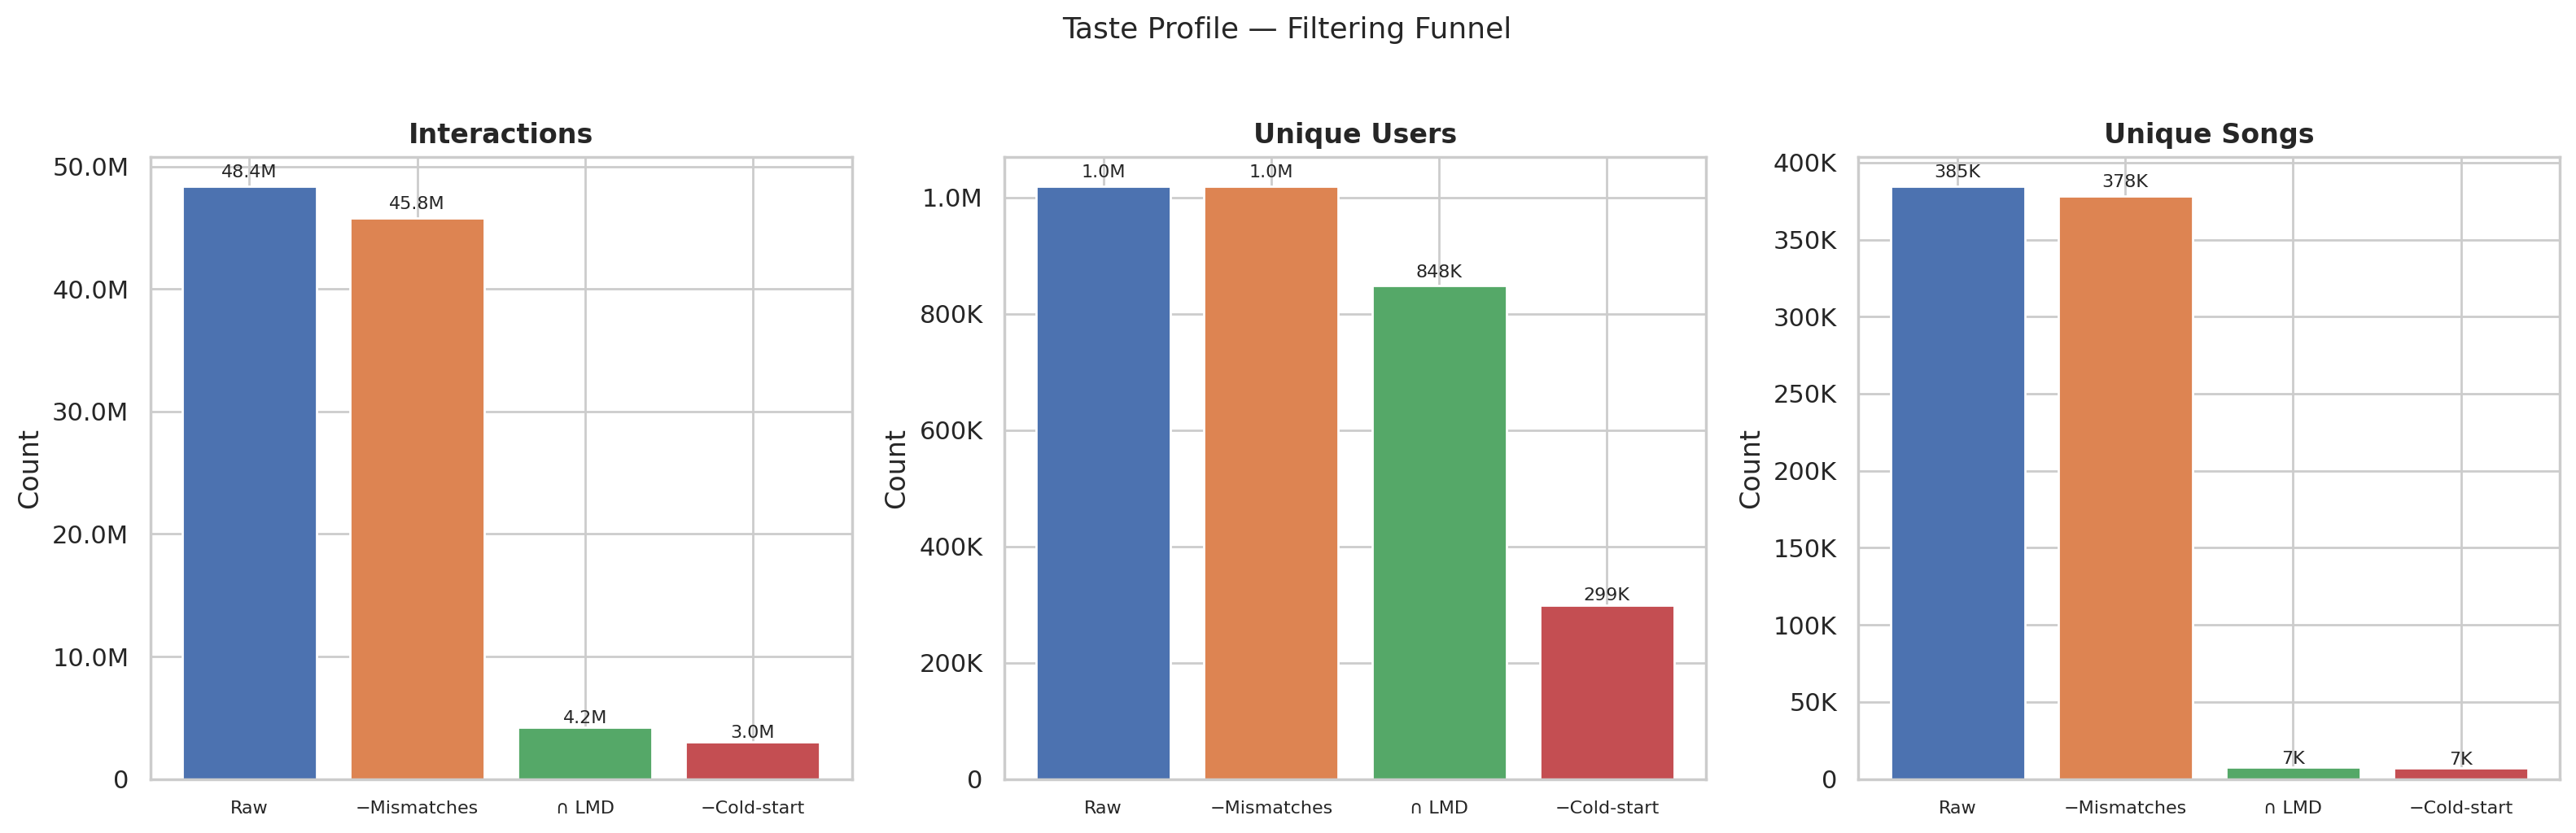

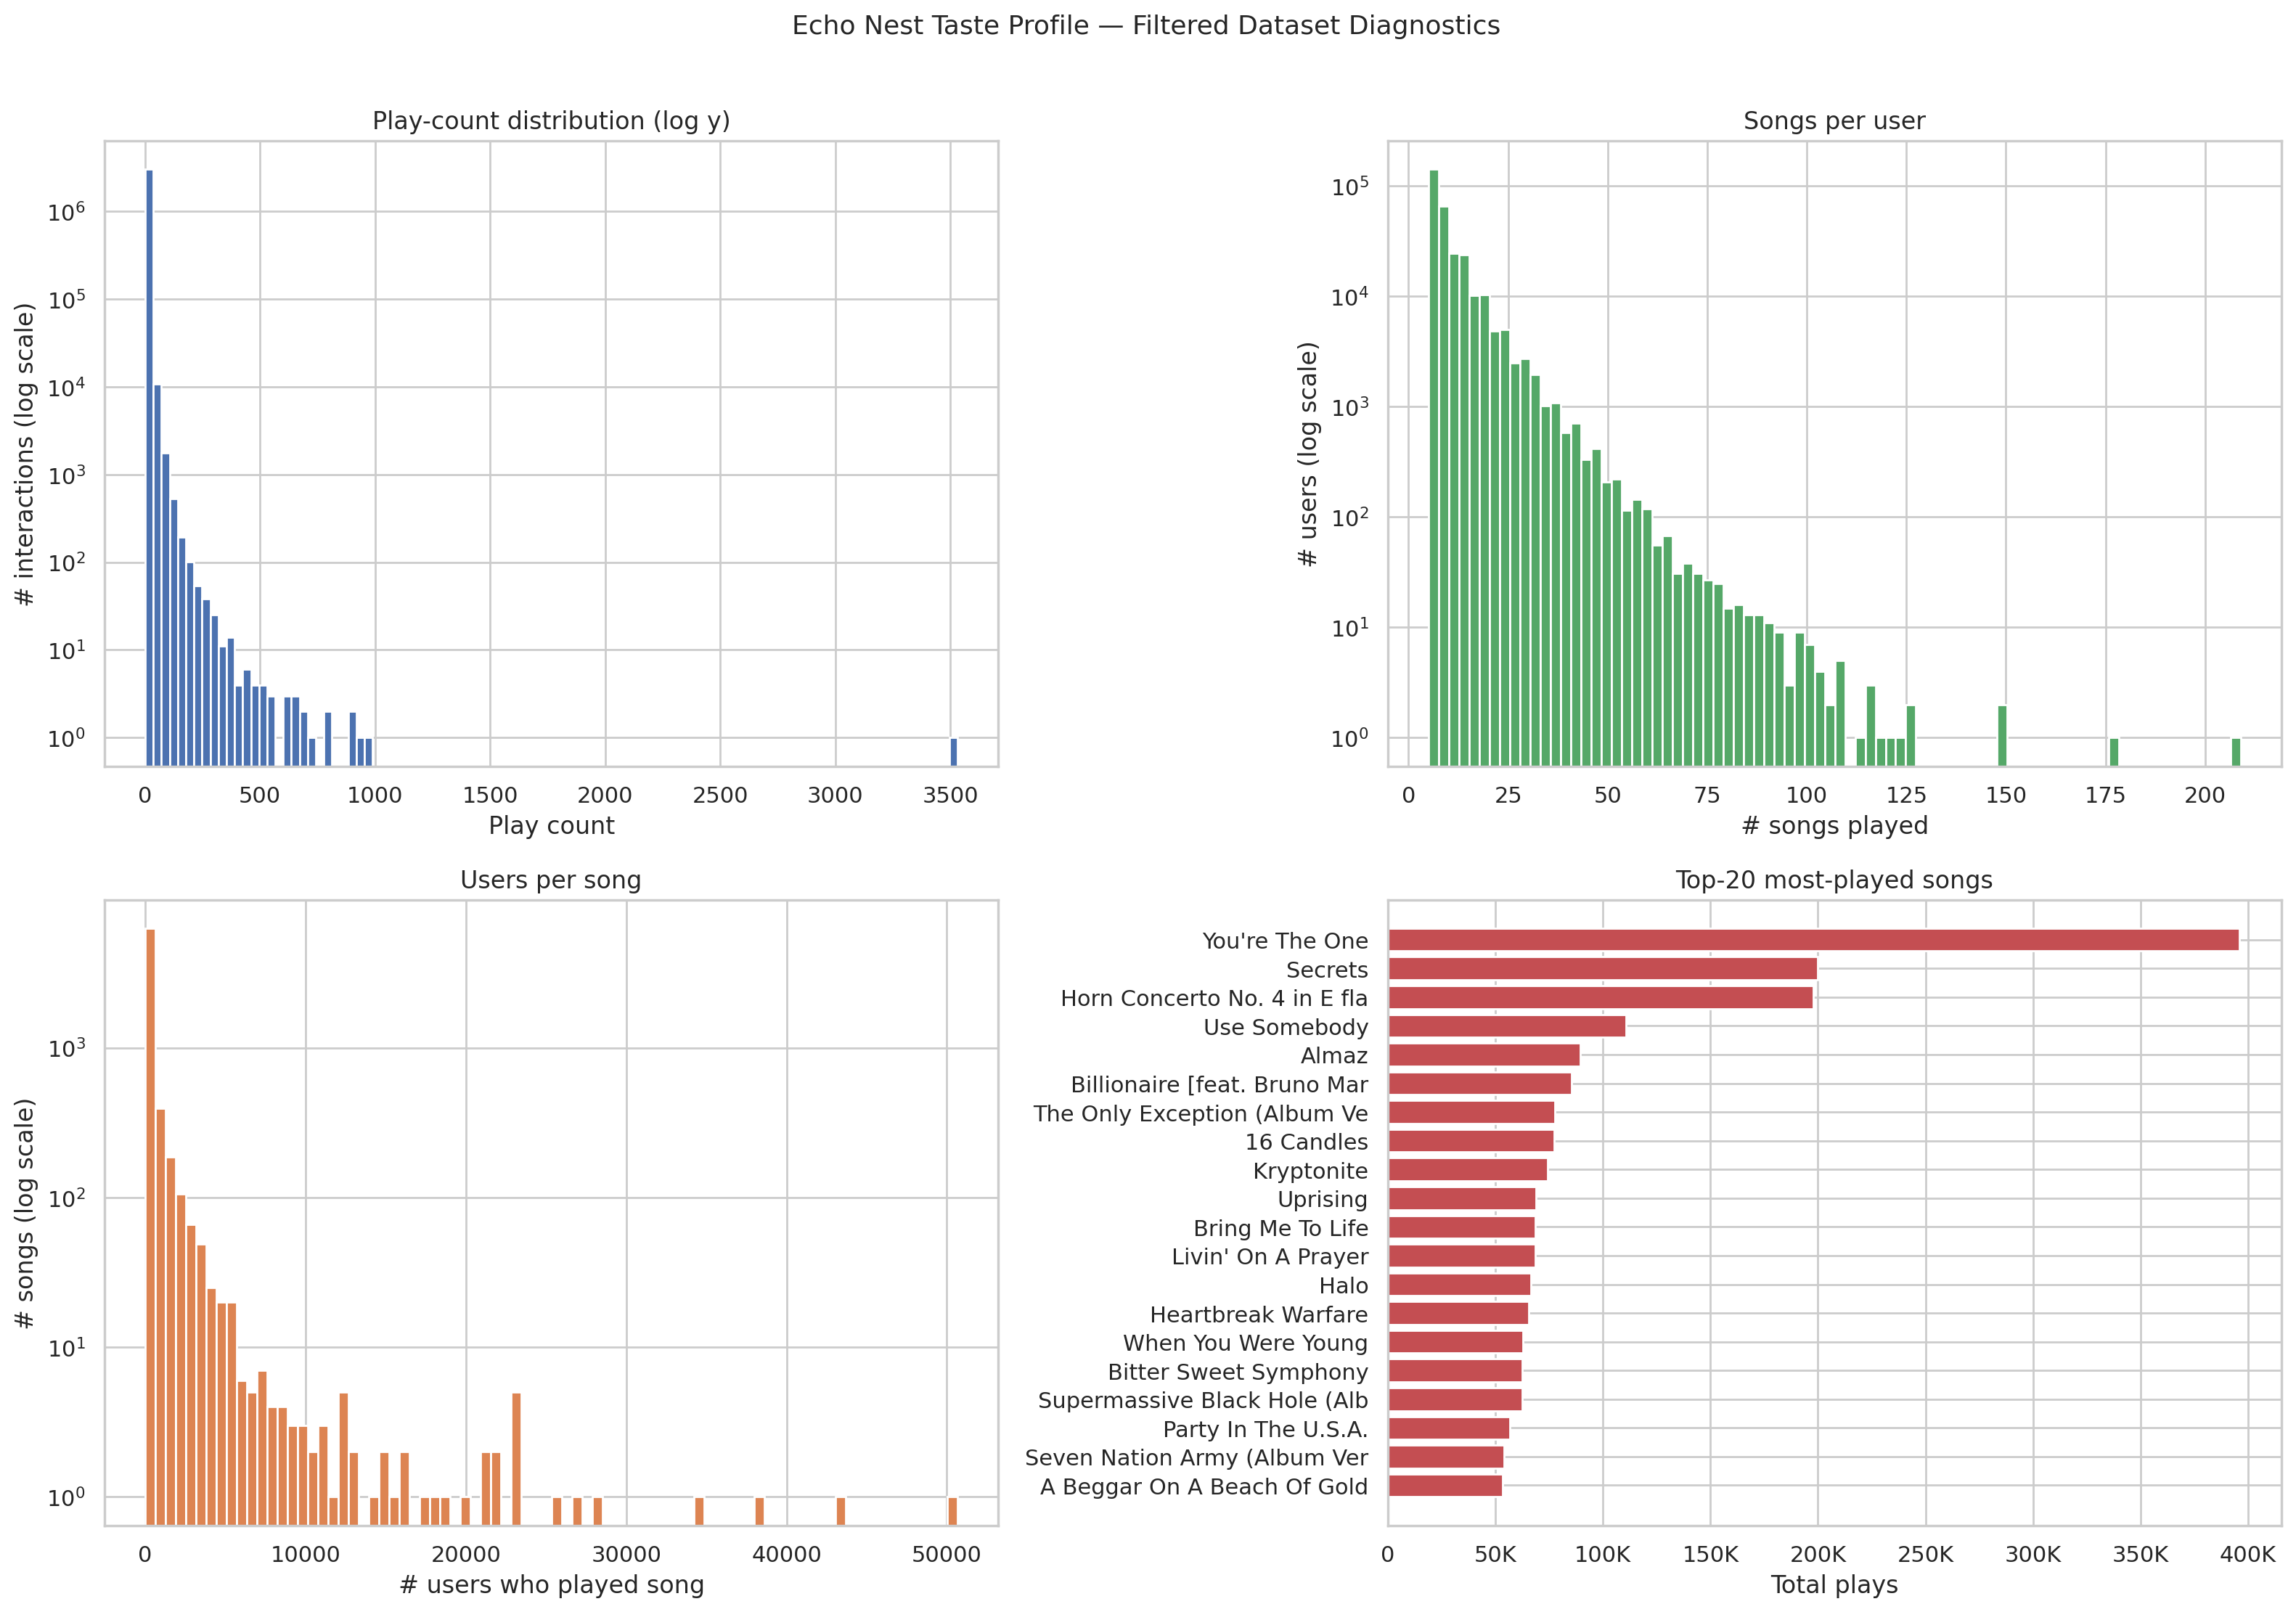

18265

In [7]:
from data.eda import plot_user_funnel, plot_user_diagnostics

plot_user_funnel(taste_df.attrs.get("filter_stats", {}))

per_user_df = pd.read_csv(PER_USER_CSV, index_col="user_id")
per_song_df = pd.read_csv(PER_SONG_CSV, index_col="song_id")
plot_user_diagnostics(taste_df, per_user_df, per_song_df)

del per_user_df, per_song_df
gc.collect()

## 3. Music Feature Extraction (jSymbolic + music21)
Extracts symbolic music features from MIDI files using jSymbolic2 and music21, including instrumentation, rhythm, pitch, and other attributes. Saves the extracted features to `data/processed/lakh_msd_features.parquet`.

In [8]:
CHUNK_SIZE = 100

if FEATURES_PQ.exists() and not FORCE_REBUILD:
    print(f"[SKIP] Section 3 — {FEATURES_PQ.name} already built. Jump to section 4.")
else:
    per_song_df = pd.read_csv(PER_SONG_CSV)
    print(f"Songs to process: {len(per_song_df):,}")


[SKIP] Section 3 — music_features.parquet already built. Jump to section 4.


In [9]:
if FEATURES_PQ.exists() and not FORCE_REBUILD:
    print("[SKIP] jSymbolic extraction — FEATURES_PQ already built.")
else:
    if not os.path.isdir(INTERIM):
        os.mkdir(INTERIM)

    INTERIM_MIDI_DIR = INTERIM / "midi_dir"

    if not os.path.exists(JSYMB_CSV):
        for i in range(((len(per_song_df)-1)//CHUNK_SIZE)+1):
            #Copy every song to one location so jSymbolic can run on all of them in one go, avoiding startup overhead
            if not os.path.isdir(INTERIM_MIDI_DIR):
                os.mkdir(INTERIM_MIDI_DIR)

            for j, row in per_song_df[i*CHUNK_SIZE:i*CHUNK_SIZE+CHUNK_SIZE].iterrows():
                lakh_row = lakh_df.loc[lakh_df['song_id'] == row['song_id']]
                source_midi_path = list(lakh_row['midi_path'])[0]
                target_midi_path = INTERIM_MIDI_DIR / os.path.basename(source_midi_path)
                shutil.copyfile(source_midi_path, target_midi_path)

            incomplete = True
            while incomplete:
                #Try adding '-Xmx12g' before '-jar'
                result = subprocess.run(['java', '-jar', JSYMBOLIC_JAR, '-configrun', JSYMB_CONFIG, INTERIM_MIDI_DIR, INTERIM / "feature_values.xml", INTERIM / "feature_definitions.xml"], capture_output=True)
                if len(result.stderr) > 0:
                    err_string = str(result.stderr)
                    idx = err_string.find('.mid')
                    if idx > -1: #Remove MIDI files which we were unable to extract features from
                        filename = err_string[idx-32:idx+4]
                        os.remove(INTERIM_MIDI_DIR / filename)
                else:
                    incomplete = False

                print(result.stdout)
                print(result.stderr)
            shutil.rmtree(INTERIM_MIDI_DIR)

            if not os.path.exists(JSYMB_CSV):
                shutil.copyfile(INTERIM / "feature_values.csv", JSYMB_CSV)
            else:
                new_file = open(INTERIM / "feature_values.csv", 'r')
                feature_txt_data = new_file.read()
                new_file.close()
                idx = feature_txt_data.find("\n")

                interim_file = open(JSYMB_CSV, 'a')
                interim_file.write(feature_txt_data[idx+1:])
                interim_file.close()
    else:
        print("[SKIP] jSymbolic extraction — JSYMB_CSV already exists.")


[SKIP] jSymbolic extraction — FEATURES_PQ already built.


In [10]:
def _load_jsymbolic_with_song_ids(interim_csv: Path, lakh: pd.DataFrame) -> pd.DataFrame:
    """Load interim.csv, map MIDI hash → song_id, return features indexed by song_id."""
    raw = pd.read_csv(interim_csv)
    raw.rename(columns={raw.columns[0]: "raw_path"}, inplace=True)
    raw["midi_hash"] = raw["raw_path"].apply(
        lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
    )
    raw = raw.dropna(subset=["midi_hash"])
    lakh_lookup = (
        lakh[["midi_path", "song_id"]].copy()
        .assign(midi_hash=lambda d: d["midi_path"].apply(
            lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
        ))
        .dropna(subset=["midi_hash", "song_id"])
        .drop_duplicates("midi_hash")
    )
    merged = raw.merge(lakh_lookup[["midi_hash", "song_id"]], on="midi_hash", how="inner")
    feat_cols = [c for c in merged.columns if c not in ("raw_path", "midi_hash", "song_id")]
    result = merged[["song_id"] + feat_cols].drop_duplicates("song_id").set_index("song_id")
    del raw, lakh_lookup, merged
    return result.apply(pd.to_numeric, errors="coerce")


In [11]:
#music21 native feature extraction
extractors = []
for feature in music21.features.base.extractorsById("all"):
    if not ('jSymbolic' in feature.__module__):
        extractors += [feature]

if not os.path.exists(M21_CSV) and not (FEATURES_PQ.exists() and not FORCE_REBUILD):
    for i in range(((len(per_song_df)-1)//CHUNK_SIZE)+1):
        music21_dataset = music21.features.base.DataSet(featureExtractors=extractors, classLabel='song_id')

        for j, row in per_song_df[i*CHUNK_SIZE:i*CHUNK_SIZE+CHUNK_SIZE].iterrows():
            lakh_row = lakh_df.loc[lakh_df['song_id'] == row['song_id']]
            music21_dataset.addData(list(lakh_row['midi_path'])[0], classValue=row['song_id'])

        music21_dataset.process()
        tempfile = INTERIM / "temp.csv"
        music21_dataset.write(str(tempfile))

        if not os.path.exists(M21_CSV):
            shutil.copyfile(tempfile, M21_CSV)
        else:
            new_file = open(tempfile, 'r')
            feature_txt_data = new_file.read()
            idx = feature_txt_data.find("\n")
            new_file.close()
            outfile = open(M21_CSV, 'a')
            outfile.write(feature_txt_data[idx:])
            outfile.close()

        print(f"Processed chunk {i}")
else:
    print("[SKIP] music21 extraction — M21_CSV exists or FEATURES_PQ already built.")


[SKIP] music21 extraction — M21_CSV exists or FEATURES_PQ already built.


In [12]:
if FEATURES_PQ.exists() and not FORCE_REBUILD:
    music_features_df = pd.read_parquet(FEATURES_PQ)
    print(f"[SKIP] merged dataframe of music features creation (already built).")   
else:
    if not JSYMB_CSV.exists():
        raise FileNotFoundError(
            f"{JSYMB_CSV} not found. Run: scripts/extract_features.sh"
        )
    jsym_df = _load_jsymbolic_with_song_ids(JSYMB_CSV, lakh_df)
    print(f"jSymbolic: {jsym_df.shape[0]:,} songs × {jsym_df.shape[1]} features  "
          f"(NaN rate: {jsym_df.isnull().mean().mean():.1%})")

    music21_df = pd.read_csv(M21_CSV).drop(columns=["Identifier"])
    music_features_df = pd.merge(
        music21_df, jsym_df.reset_index(), how="left", on="song_id"
    )
    PROCESSED.mkdir(parents=True, exist_ok=True)
    music_features_df.to_parquet(FEATURES_PQ, index=False)
    print(f"saved → {FEATURES_PQ}  {music_features_df.shape}")
    display(music_features_df.head())

    del jsym_df, music21_df
    gc.collect()

print(f"Features: {music_features_df.shape[0]:,} songs × {music_features_df.shape[1]} cols")
display(music_features_df.head()) 

# some light analsyis of the features
display(music_features_df.describe())


[SKIP] merged dataframe of music features creation (already built).
Features: 7,050 songs × 1527 cols


Quality  Tonal_Certainty  Unique_Note_Quarter_Lengths  \
0        0         0.907653                           44   
1        0         0.851214                           17   
2        0         1.358952                           11   
3        0         0.943389                           17   
4        1         1.623611                           53   

   Most_Common_Note_Quarter_Length  \
0                             0.25   
1                             0.25   
2                             0.50   
3                             0.25   
4                             0.50   

   Most_Common_Note_Quarter_Length_Prevalence  Range_of_Note_Quarter_Lengths  \
0                                    0.315696                      11.583333   
1                                    0.519503                       3.916667   
2                                    0.463811                       3.750000   
3                                    0.806574                      35.750000   
4                                    0.375518                       8.166667   

   Unique_Pitch_Class_Set_Simultaneities  Unique_Set_Class_Simultaneities  \
0                                    109                               32   
1                                     47                               20   
2                                     74                               26   
3                                     44                               18   
4                                     68                               26   

   Most_Common_Pitch_Class_Set_Simultaneity_Prevalence  \
0                                           0.124476     
1                                           0.180788     
2                                           0.124490     
3                                           0.126595     
4                                           0.115734     

   Most_Common_Set_Class_Simultaneity_Prevalence  \
0                                       0.351635   
1                                       0.587192   
2                                       0.320408   
3                                       0.247301   
4                                       0.304161   

   Major_Triad_Simultaneity_Prevalence  Minor_Triad_Simultaneity_Prevalence  \
0                             0.295893                             0.108550   
1                             0.296552                             0.398030   
2                             0.340816                             0.126531   
3                             0.212954                             0.066732   
4                             0.267814                             0.328551   

   Dominant_Seventh_Simultaneity_Prevalence  \
0                                  0.029338   
1                                  0.000985   
2                                  0.059184   
3                                  0.000000   
4                                  0.004782   

   Diminished_Triad_Simultaneity_Prevalence  Triad_Simultaneity_Prevalence  \
0                                  0.012154                       0.362531   
1                                  0.000000                       0.587192   
2                                  0.046939                       0.367347   
3                                  0.000000                       0.247301   
4                                  0.000478                       0.304639   

   Diminished_Seventh_Simultaneity_Prevalence  \
0                                    0.000000   
1                                    0.000000   
2                                    0.006122   
3                                    0.000000   
4                                    0.000000   

   Incorrectly_Spelled_Triad_Prevalence  Chord_Bass_Motion_0  \
0                              0.009164                  1.0   
1                              0.000000                  1.0   
2                              0.016393                  1.0   
3                            

Quality  Tonal_Certainty  Unique_Note_Quarter_Lengths  \
count  7050.000000      7050.000000                  7050.000000   
mean      0.180000         1.052155                    27.832482   
std       0.384215         0.209898                    15.589250   
min       0.000000         0.000000                     1.000000   
25%       0.000000         0.894997                    17.000000   
50%       0.000000         1.030415                    25.000000   
75%       0.000000         1.194882                    35.000000   
max       1.000000         1.717526                   170.000000   

       Most_Common_Note_Quarter_Length  \
count                      7050.000000   
mean                          0.328144   
std                           0.223595   
min                           0.000000   
25%                           0.250000   
50%                           0.250000   
75%                           0.333333   
max                           4.000000   

       Most_Common_Note_Quarter_Length_Prevalence  \
count                                 7050.000000   
mean                                     0.520513   
std                                      0.165983   
min                                      0.089501   
25%                                      0.402310   
50%                                      0.509310   
75%                                      0.639802   
max                                      1.000000   

       Range_of_Note_Quarter_Lengths  Unique_Pitch_Class_Set_Simultaneities  \
count                    7050.000000                            7050.000000   
mean                       14.909385                              80.182270   
std                        22.183723                              47.932332   
min                         0.000000                               0.000000   
25%                         6.750000                              50.000000   
50%                        10.166667                              72.000000   
75%                        15.750000                             100.000000   
max                       566.833333                             686.000000   

       Unique_Set_Class_Simultaneities  \
count                      7050.000000   
mean                         30.692340   
std                          15.633507   
min                           0.000000   
25%                          21.000000   
50%                          29.000000   
75%                          38.000000   
max                         164.000000   

       Most_Common_Pitch_Class_Set_Simultaneity_Prevalence  \
count                                        7050.000000     
mean                                            0.170632     
std                                             0.090870     
min                                             0.000000     
25%                                             0.110264     
50%                                             0.151663     
75%                                             0.211057     
max                                             1.000000     

       Most_Common_Set_Class_Simultaneity_Prevalence  \
count                                    7050.000000   
mean                                        0.397406   
std                                         0.165584   
min                                         0.000000   
25%                                         0.272526   
50%                                         0.371952   
75%                                         0.500852   
max                                         1.000000   

       Major_Triad_Simultaneity_Prevalence  \
count                          7050.000000   
mean                              0.226883   
std                               0.173420   
min                               0.000000   
25%                               0.084762   
50%                               0.199803   
75%                               0.337767   
max               

>**Note**: there are a few features like Basic_Pitch_Histogram_XX that are mostly populated with zeros, but we think that during the autoencoder training the model will learn to combine those features in a meaningfull way and give more expressiveness to the more informative ones.

## 4. Knowledge Graph Construction

In [13]:
from data.kg import (
    INTERIM_KG_FEATURES,
    select_kg_columns, load_music_features, merge_parquet_with_interim,
    load_or_build_kg_taste_profile,
)
from data.kg.tempo_classes import add_tempo_class_column, tempo_class_table

if KG_INPUT_PQ.exists() and not FORCE_REBUILD:
    merged = pd.read_parquet(KG_INPUT_PQ)
    merged = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    print(f"[SKIP] kg_input: {merged.shape}")
else:
    kg_df      = select_kg_columns(lakh_df)
    interim_df = load_music_features(FEATURES_PQ, INTERIM_KG_FEATURES)
    merged     = merge_parquet_with_interim(kg_df, interim_df, join_col="song_id", how="inner")
    merged     = merged.dropna(subset=["Mean_Tempo"]).reset_index(drop=True)
    merged     = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    out = merged.copy(); out["tempo_class"] = out["tempo_class"].astype("string")
    out.to_parquet(KG_INPUT_PQ, index=False)
    del out, kg_df, interim_df
    print(f"saved → {KG_INPUT_PQ.relative_to(ROOT)}  shape={merged.shape}")

kg_song_ids = set(merged["song_id"].dropna().unique())
taste = load_or_build_kg_taste_profile(
    cache_path=KG_TASTE_PQ, taste_source=TASTE_PQ,
    kg_song_ids=kg_song_ids, min_plays_per_user=5, force_rebuild=FORCE_REBUILD,
)
print(f"KG: {len(merged):,} tracks  |  taste: {len(taste):,} interactions "
      f"({taste['user_id'].nunique():,} users, {taste['song_id'].nunique():,} songs)")

try:
    del lakh_df, taste_df
except NameError:
    pass
gc.collect()


[SKIP] kg_input: (7113, 55)
[user_data] loading cache!
KG: 7,113 tracks  |  taste: 2,853,630 interactions (285,037 users, 7,010 songs)


57327

In [14]:
from data.kg import KGBuilder

if ONTO_OUT.exists() and not FORCE_REBUILD:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=False)
    print(f"[SKIP] rich KG: {ONTO_OUT.relative_to(ROOT)}")
    display(builder.stats())
else:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=True)
    builder.add_music_concept_hierarchy()   # OWL class hierarchy + equivalentClass links
    builder.add_tempo_class_individuals()
    builder.add_key_mode_individuals()
    counts = builder.populate_from_dataframe(merged, max_rows=None, verbose=True)
    builder.save()
    print(f"saved → {ONTO_OUT.relative_to(ROOT)}  ({ONTO_OUT.stat().st_size/1024:,.1f} KiB)")


populate: 100%|██████████| 7.11k/7.11k [00:07<00:00, 1.01krow/s, artists=3338, perf=6059, tracks=6059]


KG population summary: {'artists': 3668, 'tracks': 7013, 'performances': 7013, 'genres': 645, 'instruments': 129, 'rows_skipped': 0}
saved → data/ontology/knowledge_graph_full_with_users.ttl  (11,750.0 KiB)


In [15]:
from data.kg import (
    INSTRUMENT_ROOT, GENRE_ROOT,
    resolve_labels, build_parent_graph, fetch_qid_metadata,
    enrich_graph_with_wikidata,
    unique_decades_from_dataframe, resolve_decades,
    collect_decade_qids_for_metadata, add_decades_to_graph,
)
from data.kg.kg_builder import _iter_strings

FORCE_REBUILD_WD = False

# Enrichment is considered done when ALL Wikidata cache files exist.
# ONTO_OUT is created by the previous cell before enrichment runs, so
# it cannot be used as a done-signal here.
_WD_DONE = all([
    WD_INSTR_PQ.exists(), WD_INSTR_CHAINS_PQ.exists(),
    WD_GENRE_PQ.exists(), WD_GENRE_CHAINS_PQ.exists(),
    WD_DECADES_PQ.exists(),
])

if _WD_DONE and not FORCE_REBUILD_WD:
    print("[SKIP] Wikidata enrichment — all cache files present.")
else:
    instr_labels: set[str] = set()
    for cell in merged["midi_instrument_names"]:
        instr_labels.update(_iter_strings(cell))
    genre_labels: set[str] = set()
    for col in ("primary_genre", "top3_genres", "artist_terms"):
        for cell in merged[col]:
            genre_labels.update(([cell.strip()] if isinstance(cell, str) and cell.strip()
                                  else _iter_strings(cell)))

    instr_map = resolve_labels(sorted(instr_labels), INSTRUMENT_ROOT,
                               cache_path=WD_INSTR_PQ, force_refresh=FORCE_REBUILD_WD, parallel=6, verbose=True)
    genre_map = resolve_labels(sorted(genre_labels), GENRE_ROOT,
                               cache_path=WD_GENRE_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)

    instr_chains = build_parent_graph(
        leaf_qids=[q for q in instr_map.values() if q], type_root=INSTRUMENT_ROOT,
        cache_path=WD_INSTR_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)
    genre_chains = build_parent_graph(
        leaf_qids=[q for q in genre_map.values() if q], type_root=GENRE_ROOT,
        cache_path=WD_GENRE_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)

    all_qids: set[str] = {q for q in (*instr_map.values(), *genre_map.values()) if q}
    all_qids.update(instr_chains.keys())
    all_qids.update(genre_chains.keys())
    qid_metadata = fetch_qid_metadata(sorted(all_qids), cache_path=WD_QID_META_PQ,
                                      force_refresh=FORCE_REBUILD_WD, parallel=6, batch_size=50)

    enrich_counts = enrich_graph_with_wikidata(
        builder, instrument_map=instr_map, genre_map=genre_map,
        instrument_chains=instr_chains, genre_chains=genre_chains,
        qid_metadata=qid_metadata, add_hierarchy=True, verbose=False)
    print(f"Enriched — instruments: {enrich_counts.get('instrument_links',0):,}  "
          f"genres: {enrich_counts.get('genre_links',0):,}  "
          f"hierarchy edges: {enrich_counts.get('broader_edges',0):,}")

    decade_starts    = unique_decades_from_dataframe(merged, year_col="year")
    decade_qids      = resolve_decades(decade_starts, cache_path=WD_DECADES_PQ,
                                       force_refresh=FORCE_REBUILD_WD, parallel=4, verbose=False)
    decade_meta_qids = collect_decade_qids_for_metadata(decade_qids)
    qid_metadata     = fetch_qid_metadata(decade_meta_qids, cache_path=WD_QID_META_PQ,
                                          force_refresh=FORCE_REBUILD_WD, parallel=4, batch_size=50, verbose=False)
    add_decades_to_graph(builder, merged, year_col="year", track_id_col="track_id",
                         decade_qids=decade_qids, qid_metadata=qid_metadata, verbose=False)

    builder.save()
    print(f"[SAVED] → {ONTO_OUT.name}  ({ONTO_OUT.stat().st_size/1024:,.1f} KiB)")


[wikidata] resolving 129 new labels (type_root=Q110295396, workers=6) ...


labels: 100%|██████████| 129/129 [01:42<00:00,  1.25item/s]


[wikidata] cache -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/wikidata_instruments.json
[wikidata] resolving 645 new labels (type_root=Q188451, workers=10) ...


labels: 100%|██████████| 645/645 [11:47<00:00,  1.10s/item]


[wikidata] cache -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/wikidata_genres.json
[wikidata] parent-graph BFS round 1: fetching direct parents for 44 QIDs ...


...

[wikidata] parent-graph BFS round 5: fetching direct parents for 1 QIDs ...


direct-parents (r5): 100%|██████████| 1/1 [00:00<00:00,  2.70item/s]


[wikidata] has parent graph!(516 nodes, 5 BFS rounds)
[wikidata] fetching metadata for 673 new QIDs (languages=['en', 'pt'], workers=6, batch=50) ...


qid-meta: 100%|██████████| 14/14 [00:01<00:00,  9.25batch/s]


[wikidata] cached!
Enriched — instruments: 63  genres: 457  hierarchy edges: 0
[SAVED] → knowledge_graph_full_with_users.ttl  (12,042.8 KiB)


In [16]:
# ── Retroactive patch: fix WD nodes whose rdfs:label was stored as a bare QID
# (e.g. wd:Q6927 rdfs:label "Q6927"@en instead of "20th century"@en).
# This happens when fetch_qid_metadata fails silently for a batch (network
# error → batch_out={}) and add_decades_to_graph falls back to label=qid.
# The code-level auto-fetch fix in add_decades_to_graph/enrich_graph_with_wikidata
# prevents this on future rebuilds, but the existing TTL needs a targeted patch.

import re as _re
from rdflib.namespace import OWL, RDF, RDFS
from rdflib import Literal
from data.kg.wikidata_mapping import fetch_qid_metadata, _attach_qid_metadata, WD

_QID_RE  = _re.compile(r"^Q\d+$")
_WD_PFX  = "http://www.wikidata.org/entity/"

# Find all wd: owl:Class nodes whose ONLY English label is the bare QID string.
bad: dict[str, object] = {}  # qid -> URIRef
for node in builder.g.subjects(RDF.type, OWL.Class):
    if not str(node).startswith(_WD_PFX):
        continue
    qid = str(node).rsplit("/", 1)[-1]
    en_labels = [
        str(lbl) for lbl in builder.g.objects(node, RDFS.label)
        if getattr(lbl, "language", None) == "en"
    ]
    if en_labels and all(_QID_RE.match(l) for l in en_labels):
        bad[qid] = node

if not bad:
    print("[patch] No QID-as-label nodes found — graph is clean.")
else:
    print(f"[patch] Found {len(bad)} WD nodes with QID-as-label: {sorted(bad)[:8]} ...")
    meta = fetch_qid_metadata(sorted(bad), verbose=True)
    for qid, node in bad.items():
        builder.g.remove((node, RDFS.label,   None))
        builder.g.remove((node, RDFS.comment, None))
        _attach_qid_metadata(builder.g, node, qid, meta.get(qid, {}),
                             fallback_label=None)
    builder.save()
    print(f"[patch] Patched {len(bad)} nodes and saved → {ONTO_OUT.name}")
gc.collect()


[patch] Found 12 WD nodes with QID-as-label: ['Q1740992', 'Q19022', 'Q34644', 'Q34653', 'Q35014', 'Q35024', 'Q35724', 'Q36297'] ...
[wikidata] fetching metadata for 12 new QIDs (languages=['en', 'pt'], workers=4, batch=50) ...


qid-meta: 100%|██████████| 1/1 [00:00<00:00,  4.01batch/s]


[patch] Patched 12 nodes and saved → knowledge_graph_full_with_users.ttl


2016

In [17]:
from data.kg import ensure_listening_sidecar, merge_sidecar_into_graph

# Listening events are kept in a sidecar .nt file (not in builder.g)
# to avoid loading 8M+ triples into RAM during KG construction.
ensure_listening_sidecar(
    builder, taste,
    sidecar_path  = LISTENING_NT,
    merged        = merged,
    force_rebuild = FORCE_REBUILD,
    batch_size    = 100_000,
    flush_every   = 1_000_000,
    verbose       = True,
)
print(f"[ TTL] {ONTO_OUT.name}  ({ONTO_OUT.stat().st_size/1024/1024:,.1f} MiB)")
print(f"[  NT] {LISTENING_NT.name}  ({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")

LOAD_SIMPLE = True
if ONTO_OUT_SIMPLE.exists() and LISTENING_NT_SIM.exists() and not FORCE_REBUILD:
    if LOAD_SIMPLE:
        builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE,
                                   overwrite_copy=False, simple=True)
        print(f"[SKIP] simple KG: {len(builder_simple.g):,} triples")
else:
    builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE,
                               overwrite_copy=True, simple=True)
    builder_simple.add_tempo_class_individuals()
    builder_simple.populate_from_dataframe(merged, max_rows=None, verbose=False)
    builder_simple.save()
    ensure_listening_sidecar(
        builder_simple, taste,
        sidecar_path  = LISTENING_NT_SIM,
        merged        = merged,
        simple        = True,
        force_rebuild = FORCE_REBUILD,
        batch_size    = 100_000,
        verbose       = True,
    )
    print(f"[SAVED] simple → {ONTO_OUT_SIMPLE.name} + {LISTENING_NT_SIM.name}")
gc.collect()


listening→nt: 100%|██████████| 2.85M/2.85M [00:26<00:00, 109krow/s, interactions=2853630, listeners=285037, orphan=0]


[listening→nt] wrote 2,853,630 interactions for 285,037 listeners (orphaned rows: 0) -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/ontology/listening_triples.nt (1,509.6 MiB)
[SAVED] schema additions → knowledge_graph_full_with_users.ttl
[ TTL] knowledge_graph_full_with_users.ttl  (11.8 MiB)
[  NT] listening_triples.nt  (1,509.6 MiB)


listening→nt: 100%|██████████| 2.85M/2.85M [00:26<00:00, 108krow/s, interactions=2853630, listeners=285037, orphan=0]


[listening→nt] wrote 2,853,630 interactions for 285,037 listeners (orphaned rows: 0) -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/ontology/listening_triples_simple.nt (716.3 MiB)
[SAVED] schema additions → knowledge_graph_simple.ttl
[SAVED] simple → knowledge_graph_simple.ttl + listening_triples_simple.nt


0

## 5. GraphDB Upload & Artefact Export *(local only)*

Runs **only** when `USE_GRAPHDB=True` (i.e. a local `GRAPHDB_URL` is set).

**What it does**
1. Bootstraps the `music_recsys` repository (creates it if absent).
2. Uploads all four RDF files (full + simple ontology, full + simple listening NT).
3. Exports:
   - `graphdb/pykeen_triples.tsv` — head/rel/tail for PyKEEN
   - `graphdb/node_dict.json` — `{type: {uri: int}}`
   - `graphdb/hetero_edges.parquet` — typed edges for PyG HeteroData
   - `kg_stats/*.csv` — per-query stat tables
   - `kg_plots/*.png` — distribution charts

On Colab (or when `USE_GRAPHDB=False`) this cell is a no-op; downstream cells
read the pre-computed artefacts from Drive instead.

In [18]:
if ON_COLAB:
    print("[SKIP] Section 5.0 — running on Colab; reading pre-computed artefacts.")
elif not USE_GRAPHDB:
    print("[SKIP] Section 5.0 — USE_GRAPHDB=False; using rdflib in-memory path.")
else:
    from data.kg.graphdb import GraphDBConfig, GraphDBClient, KGRepo

        # Pass absolute paths from nb_env so files always land under the project
    # root regardless of what directory the Jupyter process was launched from.
    _cfg = GraphDBConfig.from_env(
        out_dir   = KG_GRAPHDB_DIR,
        stats_dir = KG_STATS_DIR,
        plots_dir = KG_PLOTS_DIR,
    )
    _client = GraphDBClient(_cfg)

    print("GraphDB ping →", _client.ping())

    _repo = KGRepo(_client, _cfg)
    _repo.bootstrap()

    # ── Only the rich KG (ontology + listening sidecar).
    _RICH_FILES = [ONTO_OUT, LISTENING_NT]

    # ── Clear & reload flag ────────────────────────────────────────────
    # Set to True ONLY when you need a completely clean reload (e.g. after
    # a schema change).  Clearing the repo deletes every triple and forces
    # a full re-upload on the next run.
    RELOAD_GRAPHDB = True    # ← flip to True only for a forced clean reload

    if RELOAD_GRAPHDB:
        print("[RELOAD] Clearing all triples from the repository …")
        _client.clear_repository()
        # Delete the upload-state cache so upload_kg re-uploads everything
        _state = _cfg.out_dir / _cfg.upload_state_file
        if _state.is_file():
            _state.unlink()
            print(f"[RELOAD] Deleted upload cache: {_state.relative_to(ROOT)}")
        print(f"[RELOAD] Repo cleared — triple count: {_client._session.get(_cfg.repo_endpoint + '/size').text}")

    # ── Upload (skips files whose SHA-256 hasn't changed) ──────────────
    # FORCE_UPLOAD=True bypasses the SHA-256 cache and re-uploads everything.
    # Leave False on normal runs — the cache will skip files that haven't
    # changed, preventing blank-node duplication in GraphDB.
    FORCE_UPLOAD = False      # ← flip to True only to force re-upload

    sent = _repo.upload_kg(_RICH_FILES, force=FORCE_UPLOAD, replace_first=False)
    print(f"Files uploaded this run : {[p.name for p in sent] or '(all cached)'}")
    _explicit = int(_client._session.get(_cfg.repo_endpoint + '/size').text)
    print(f"Explicit triples stored : {_explicit:,}")

    # ── Export artefacts ───────────────────────────────────────────────
    # INFO level so the equivalence-merge and triple-count stats come through
    logging.getLogger("data.kg.graphdb").setLevel(logging.INFO)
    artefacts = _repo.export_all()
    _client.close()

    # ── Summary ────────────────────────────────────────────────────────
    print(f"\n[OK] Section 5.0 complete — {len(artefacts)} artefacts")
    print(f"     out_dir   : {_cfg.out_dir.relative_to(ROOT)}")
    print(f"     stats_dir : {_cfg.stats_dir.relative_to(ROOT)}")
    print(f"     plots_dir : {_cfg.plots_dir.relative_to(ROOT)}")

    # ── Quick results preview ──────────────────────────────────────────
    # NOTE on the two triple counts:
    #   • "Explicit triples stored" above = /size REST endpoint
    #     = only the triples present in your uploaded files.
    #   • "Total incl. inferred" below    = SPARQL COUNT(*) with infer=true
    #     = explicit + triples added by the RDFS+ reasoner
    #     (e.g. rdfs:subClassOf closure, mo:performer range → foaf:Agent).
    #   Both numbers are correct. PyKEEN uses the inferred total.
    _tc = _cfg.stats_dir / "triple_count.csv"
    if _tc.is_file():
        _n = int(pd.read_csv(_tc)["n"].iloc[0])
        print("\n── Triple counts ──")
        print(f"   Explicit triples stored  : {_explicit:>12,}  (uploaded files only)")
        print(f"   Total incl. inferred     : {_n:>12,}  (explicit + RDFS+ reasoner)")
        print(f"   Inferred-only difference : {_n - _explicit:>12,}")

    _nt = _cfg.stats_dir / "node_type_histogram.csv"
    if _nt.is_file():
        print("\n── Node types ──")
        _nt_df = pd.read_csv(_nt)
        _nt_df["type_short"] = _nt_df["type"].str.replace(r"^.*[/#]", "", regex=True)
        display(_nt_df[["type_short", "n"]].rename(columns={"type_short": "type"}))

    _gf = _cfg.stats_dir / "genres_simple.csv"
    if _gf.is_file():
        print("\n── Top 15 genres ──")
        display(pd.read_csv(_gf).head(15))

    _kf = _cfg.stats_dir / "confident_keys_rich.csv"
    if _kf.is_file():
        print("\n── Key distribution (confidence ≥ 0.8) ──")
        display(pd.read_csv(_kf))

    _rf = _cfg.stats_dir / "relation_histogram.csv"
    if _rf.is_file():
        print("\n── Top 20 relations ──")
        _rf_df = pd.read_csv(_rf)
        _rf_df["r_short"] = _rf_df["r"].str.replace(r"^.*[/#]", "", regex=True)
        display(_rf_df[["r_short", "n"]].rename(columns={"r_short": "relation"}).head(20))


GraphDB ping → True
[RELOAD] Clearing all triples from the repository …
[RELOAD] Repo cleared — triple count: 0
Files uploaded this run : ['knowledge_graph_full_with_users.ttl', 'listening_triples.nt']
Explicit triples stored : 12,915,523

[OK] Section 5.0 complete — 21 artefacts
     out_dir   : data/processed/graphdb
     stats_dir : data/final/kg_stats
     plots_dir : data/final/kg_plots

── Triple counts ──
   Explicit triples stored  :   12,915,523  (uploaded files only)
   Total incl. inferred     :   19,111,101  (explicit + RDFS+ reasoner)
   Inferred-only difference :    6,195,578

── Node types ──


,type,n
0,Listener,285037
1,Performance,7013
2,Event,7013
3,MSDTrack,7013
4,Track,7013
5,Performer,3668
6,ElementOfMusic,797
7,Genre,645
8,Genre,645
9,Instrument,129



── Top 15 genres ──


,genreLabel,n_artists
0,rock,2117
1,pop,1062
2,electronic,1037
3,pop rock,814
4,hip hop,381
5,jazz,349
6,alternative rock,337
7,indie rock,290
8,disco,282
9,soft rock,277



── Key distribution (confidence ≥ 0.8) ──


,keyLabel,n_high_confidence
0,C,211
1,G,196
2,D,150
3,A,103
4,F,98
5,E,80
6,B,63
7,A#,51
8,C#,50
9,F#,38



── Top 20 relations ──


,relation,n
0,type,612827
1,instrument,56891
2,factor,56891
3,hasGenre,18136
4,subClassOf,12167
5,hasTrack,7013
6,performer,7013
7,hasKey,7013
8,hasMode,7013
9,hasTempoClass,7013


**Note:** The blank nodes were removed from our list of node type, although in our database they look something like this `_:nodeXXXXX`. We have two types of blank nodes: 
- for **Listening events** (user listened to a track n times)
- and for the **association of a Performer/Artist to a genre** (artist has genre g with weight w)

---

In [19]:
# cleanup
drop_names = [
    # Section 5.1/5.2 enrichment temporaries
    "counts",
    "instr_labels", "genre_labels",
    "instr_map", "genre_map",
    "instr_chains", "genre_chains",
    "all_qids", "qid_metadata",
    "enrich_counts",
    "decade_starts", "decade_qids", "decade_meta_qids", "decade_counts",

    # Section 5.0 GraphDB upload/export temporaries
    "_cfg", "_client", "_repo", "_RICH_FILES",
    "sent", "_explicit", "artefacts",
    "_tc", "_nt", "_nt_df", "_gf", "_kf", "_rf", "_rf_df", "_n",
]

removed = []
g = globals()
for name in drop_names:
    if name in g:
        del g[name]
        removed.append(name)

collected = gc.collect()
print(f"[GC] Removed {len(removed)} temporary objects; gc.collect() -> {collected}")

[GC] Removed 28 temporary objects; gc.collect() -> 32995


### 5.1. SPARQL Queries on the KG
This section demonstrates how to run SPARQL queries on the constructed knowledge graph using the `sparql_query` function from `data.eda`. We execute pre-built queries to analyze the KG content, such as retrieving tracks by tempo class and listing top genres.

In [20]:
from data.kg.graphdb.queries import (
    QUERY_GENRES_SIMPLE, QUERY_GENRES_RICH,
    QUERY_FIND_TRACK_SIMPLE, QUERY_FIND_TRACK_RICH,
    QUERY_FIND_ARTIST_WITH_WEIGHTS,
    QUERY_CONFIDENT_KEYS_SIMPLE, QUERY_CONFIDENT_KEYS_RICH,
    query_key_mode_simple, query_key_mode_rich, query_artist_genre_weights,
)

from data.kg import KGBuilder

# ── Backend dispatcher ────────────────────────────────────────────────────────
def _sparql(sparql_str: str, rdflib_graph=None):
    """Run SPARQL against an rdflib graph or GraphDB; return DataFrame.

    Priority:
      1. ``rdflib_graph`` explicitly provided → always use it directly,
         regardless of USE_GRAPHDB.  This is correct for "simple KG" queries
         (e.g. direct mrc:hasKey on a track) that only exist in builder_simple.g
         and are NOT present in the rich KG uploaded to GraphDB.
      2. USE_GRAPHDB=True and no rdflib_graph → live GraphDB query.
      3. Fallback → raise (caller must supply a graph).
    """
    if rdflib_graph is not None:
        from data.eda import sparql_query
        return sparql_query(rdflib_graph, sparql_str)
    if USE_GRAPHDB:
        from data.kg.graphdb import GraphDBClient, GraphDBConfig
        _cfg = GraphDBConfig.from_env()
        with GraphDBClient(_cfg) as _c:
            return _c.select_df(sparql_str)
    raise RuntimeError("No SPARQL backend: USE_GRAPHDB=False and no rdflib graph supplied.")

def _load_or_query(sparql_str: str, csv_name: str, rdflib_graph=None):
    """
    Priority:
      1. ON_COLAB → load KG_STATS_DIR/<csv_name> from Drive
      2. rdflib_graph supplied → use it (see _sparql docstring)
      3. USE_GRAPHDB → live GraphDB query
    """
    import pandas as pd
    if ON_COLAB:
        csv_path = KG_STATS_DIR / csv_name
        if csv_path.exists():
            return pd.read_csv(csv_path)
        raise FileNotFoundError(
            f"Pre-computed CSV not found on Drive: {csv_path}\n"
            "Run section 5.0 locally and sync artefacts to Drive first."
        )
    return _sparql(sparql_str, rdflib_graph=rdflib_graph)

builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE, overwrite_copy=False, simple=True)
# Inject Key / Mode skos:prefLabel into the in-memory graph so SPARQL queries
# that filter LANG(?keyLabel) = "en" return labels instead of None.
builder_simple.add_key_mode_individuals()

# ── Discovery probes (run once to materialise parametric queries) ─────────────
# Simple-track probe always uses builder_simple.g — the simple KG has direct
# mrc:hasKey / mrc:hasMode on each MSDTrack node, which doesn't exist in the
# rich KG uploaded to GraphDB.
_simple_track = _load_or_query(QUERY_FIND_TRACK_SIMPLE,        "find_track_simple.csv",   rdflib_graph=builder_simple.g)
_rich_track   = _load_or_query(QUERY_FIND_TRACK_RICH,          "find_track_rich.csv",     rdflib_graph=builder.g if not USE_GRAPHDB else None)
_rich_artist  = _load_or_query(QUERY_FIND_ARTIST_WITH_WEIGHTS, "find_artist_weights.csv", rdflib_graph=builder.g if not USE_GRAPHDB else None)

print("Simple track found:"); display(_simple_track)
print("Rich track found:  "); display(_rich_track)
print("Rich artist found: "); display(_rich_artist)

_TRACK_URI_SIMPLE = str(_simple_track["title_URI"].iloc[0]) if not _simple_track.empty else None
_TRACK_URI_RICH   = str(_rich_track["title_URI"].iloc[0])   if not _rich_track.empty   else None
_ARTIST_URI_RICH  = str(_rich_artist["artist_URI"].iloc[0]) if not _rich_artist.empty  else None

print(f"\n_TRACK_URI_SIMPLE : {_TRACK_URI_SIMPLE}")
print(f"_TRACK_URI_RICH   : {_TRACK_URI_RICH}")
print(f"_ARTIST_URI_RICH  : {_ARTIST_URI_RICH}")

# ── Parametric queries (materialised with live URIs) ──────────────────────────
QUERY_KEY_MODE_SIMPLE                = query_key_mode_simple(_TRACK_URI_SIMPLE)
QUERY_KEY_MODE_RICH                  = query_key_mode_rich(_TRACK_URI_RICH)
QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY = query_artist_genre_weights(_ARTIST_URI_RICH)


Simple track found:


,title_URI,title
0,http://purl.org/ontology/mrc/resource/track/TR...,Into The Nightlife


Rich track found:  


,title_URI,title
0,http://purl.org/ontology/mrc/resource/track/TR...,Into The Nightlife


Rich artist found: 


,artist_URI,name
0,http://purl.org/ontology/mrc/resource/artist/A...,Cyndi Lauper



_TRACK_URI_SIMPLE : http://purl.org/ontology/mrc/resource/track/TRAAAGR128F425B14B
_TRACK_URI_RICH   : http://purl.org/ontology/mrc/resource/track/TRAAAGR128F425B14B
_ARTIST_URI_RICH  : http://purl.org/ontology/mrc/resource/artist/ARGE7G11187FB37E05


In [21]:
print("═══ Pair 1 — Genre ranking ════════════════════════════════")
print("SIMPLE (count only):")
display(_load_or_query(QUERY_GENRES_SIMPLE, "genres_simple.csv",
                       rdflib_graph=builder_simple.g if not USE_GRAPHDB else None))
print("\nRICH (weighted):")
display(_load_or_query(QUERY_GENRES_RICH,   "genres_rich.csv",
                       rdflib_graph=builder.g        if not USE_GRAPHDB else None))

print("\n═══ Pair 2 — Key/mode for one track ══════════════════════")
# Key/mode SIMPLE requires direct mrc:hasKey / mrc:hasMode on the track —
# only present in builder_simple.g (not in the rich KG stored in GraphDB).
# Always use the rdflib simple graph regardless of USE_GRAPHDB.
print("SIMPLE (no confidence):")
display(_load_or_query(QUERY_KEY_MODE_SIMPLE, "key_mode_simple.csv",
                       rdflib_graph=builder_simple.g))
print("\nRICH (+ keyConf / modeConf / tempo):")
display(_load_or_query(QUERY_KEY_MODE_RICH,   "key_mode_rich.csv",
                       rdflib_graph=builder.g        if not USE_GRAPHDB else None))

print("\n═══ Rich-only — Artist genre weights ══════════════════════")
display(_load_or_query(QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY, "artist_genre_weights.csv",
                       rdflib_graph=builder.g        if not USE_GRAPHDB else None))
print("(same query on simple returns 0 rows — blank node doesn't exist)")
display(_load_or_query(QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY, "artist_genre_weights_simple.csv",
                       rdflib_graph=builder_simple.g))

print("\n═══ Pair 3 — Confidence-filtered key counts ═══════════════")
# SIMPLE key counts also require direct mrc:hasKey — use builder_simple.g.
print("SIMPLE (unfiltered — no confidence available):")
display(_load_or_query(QUERY_CONFIDENT_KEYS_SIMPLE, "confident_keys_simple.csv",
                       rdflib_graph=builder_simple.g))
print("\nRICH (only kc >= 0.8):")
display(_load_or_query(QUERY_CONFIDENT_KEYS_RICH,   "confident_keys_rich.csv",
                       rdflib_graph=builder.g        if not USE_GRAPHDB else None))

gc.collect()


═══ Pair 1 — Genre ranking ════════════════════════════════
SIMPLE (count only):


,genreLabel,n_artists
0,rock,2117
1,pop,1062
2,electronic,1037
3,pop rock,814
4,hip hop,381
5,jazz,349
6,alternative rock,337
7,indie rock,290
8,disco,282
9,soft rock,277



RICH (weighted):


,genreLabel,n_artists,total_weight,avg_weight
0,rock,2117,1606.847,0.759
1,electronic,1037,695.345,0.671
2,pop,1062,674.199,0.635
3,pop rock,814,533.005,0.655
4,hip hop,381,293.127,0.769
5,jazz,349,252.908,0.725
6,trance,273,217.106,0.795
7,disco,282,216.879,0.769
8,alternative rock,337,215.815,0.640
9,ballad,264,205.558,0.779



═══ Pair 2 — Key/mode for one track ══════════════════════
SIMPLE (no confidence):


...


═══ Pair 3 — Confidence-filtered key counts ═══════════════
SIMPLE (unfiltered — no confidence available):


,keyLabel,n
0,C,1105
1,G,982
2,D,799
3,A,798
4,E,612
5,F,577
6,B,466
7,C#,413
8,A#,410
9,F#,339



RICH (only kc >= 0.8):


,keyLabel,n_high_confidence
0,C,211
1,G,196
2,D,150
3,A,103
4,F,98
5,E,80
6,B,63
7,A#,51
8,C#,50
9,F#,38


1476861

In [22]:
# SPARQL verification: genre / instrument hierarchy and decade temporal chain.
# Runs on the in-memory rdflib graph (builder.g) — works on both local and Colab.
#
# Hierarchy queries return (node, directParent) for the full domain subgraph:
#   rdfs:subClassOf* (zero-or-more) includes the leaf itself and all ancestors.
# Decade query returns one row per decade with prev/next/century links.
#
# NaN in parentLabel => root node (no parent in domain) — expected.
# NaN in nodeLabel   => WD ancestor whose metadata was not fetched; will be
#                       labelled after KG rebuild with the wikidata_mapping fix.

from data.eda import sparql_query
from collections import defaultdict

# ── SPARQL queries ─────────────────────────────────────────────────────────────

QUERY_GENRE_HIERARCHY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?nodeLabel ?parentLabel
WHERE {
    ?leaf a mrc:Genre .
    ?leaf rdfs:subClassOf* ?node .
    OPTIONAL { ?node   rdfs:label ?nodeLabel   . FILTER(LANG(?nodeLabel)   = "en") }
    OPTIONAL {
        ?node rdfs:subClassOf ?parent .
        OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
    }
}
"""

QUERY_INSTRUMENT_HIERARCHY = """
PREFIX mo:   <http://purl.org/ontology/mo/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?nodeLabel ?parentLabel
WHERE {
    ?leaf a mo:Instrument .
    ?leaf rdfs:subClassOf* ?node .
    OPTIONAL { ?node   rdfs:label ?nodeLabel   . FILTER(LANG(?nodeLabel)   = "en") }
    OPTIONAL {
        ?node rdfs:subClassOf ?parent .
        OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
    }
}
"""

QUERY_DECADE_CHAIN = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wdt:  <http://www.wikidata.org/prop/direct/>

SELECT ?decadeLabel ?centuryLabel ?prevLabel ?nextLabel
WHERE {
    ?decade a mrc:Decade ;
            rdfs:label ?decadeLabel .
    FILTER(LANG(?decadeLabel) = "en")
    OPTIONAL {
        ?decade rdfs:subClassOf ?century .
        OPTIONAL { ?century rdfs:label ?centuryLabel . FILTER(LANG(?centuryLabel) = "en") }
    }
    OPTIONAL {
        ?decade wdt:P155 ?prev .
        OPTIONAL { ?prev rdfs:label ?prevLabel . FILTER(LANG(?prevLabel) = "en") }
    }
    OPTIONAL {
        ?decade wdt:P156 ?next .
        OPTIONAL { ?next rdfs:label ?nextLabel . FILTER(LANG(?nextLabel) = "en") }
    }
}
ORDER BY ?decadeLabel
"""

# ── Display helpers ────────────────────────────────────────────────────────────

def _build_hierarchy_tree(df, node_col="nodeLabel", parent_col="parentLabel"):
    """Build {root: {child: {grandchild: ...}}} from (node, directParent) rows."""
    kids = defaultdict(list)
    has_parent = set()
    all_nodes = set()

    for _, row in df.iterrows():
        node   = row.get(node_col)
        parent = row.get(parent_col)
        if pd.isna(node):
            continue  # skip unlabelled WD nodes
        all_nodes.add(node)
        if pd.notna(parent):
            all_nodes.add(parent)
            kids[parent].append(node)
            has_parent.add(node)

    roots = sorted(n for n in all_nodes if n not in has_parent)

    def _sub(node, seen=None):
        seen = (seen or set()) | {node}
        children = sorted(set(c for c in kids.get(node, []) if c not in seen))
        return {c: _sub(c, seen) for c in children}

    return {r: _sub(r) for r in roots}


def _print_hierarchy(tree, indent=0):
    """Recursively pretty-print a nested dict as an indented tree."""
    if not tree:
        print("  (no results — check KG was built and wikidata enrichment ran)")
        return
    for node, subtree in sorted(tree.items()):
        prefix = "    " * indent + ("└─ " if indent else "")
        print(f"{prefix}{node}")
        if subtree:
            _print_hierarchy(subtree, indent + 1)


def _print_decade_chain(df):
    """Print decades grouped by century as horizontal → chains."""
    if df.empty:
        print("  (no results)")
        return
    centuries = defaultdict(list)
    for _, row in df.iterrows():
        dl = row.get("decadeLabel") or "?"
        cl = row.get("centuryLabel") or "unknown century"
        centuries[cl].append(dl)
    for century in sorted(centuries):
        print(f"  {century}:")
        print("    " + " → ".join(centuries[century]))


# ── Run ────────────────────────────────────────────────────────────────────────

if 'builder' in dir() and hasattr(builder, 'g'):
    print("═══ Genre hierarchy ══════════════════════════════════")
    _print_hierarchy(_build_hierarchy_tree(
        sparql_query(builder.g, QUERY_GENRE_HIERARCHY)))

    print("═══ Instrument hierarchy ═════════════════════════════")
    _print_hierarchy(_build_hierarchy_tree(
        sparql_query(builder.g, QUERY_INSTRUMENT_HIERARCHY)))

    print("═══ Decade temporal chain ════════════════════════════")
    _print_decade_chain(sparql_query(builder.g, QUERY_DECADE_CHAIN))
else:
    print("[SKIP] builder.g not in memory — run section 3 first.")
gc.collect()


═══ Genre hierarchy ══════════════════════════════════
Dutch-language music
    └─ Nederpop
        └─ nederpop
Hispanic American music
    └─ Hispanic American folk music
        └─ Brazilian folk music
            └─ pagode
Latin music
    └─ Latin pop
        └─ latin pop
    └─ Latin rock
        └─ latin rock
    └─ flamenco
    └─ latin
    └─ latin jazz
    └─ music of Latin America
        └─ music of Brazil
            └─ Brazilian folk music
                └─ pagode
            └─ Brazilian funk
                └─ baile funk
            └─ Brazilian jazz
                └─ brazilian jazz
            └─ bossa nova
            └─ choro
            └─ frevo
            └─ lambada
            └─ música popular brasileira
                └─ brazilian
            └─ pagode
            └─ samba
                └─ batucada
        └─ music of Cuba
            └─ Cuban rumba
                └─ rumba
            └─ mambo
        └─ music of Mexico
            └─ regional Mexican
     

24508

## 6. Train/Val/Test Split + Baselines
Per-user 70/10/20 split. User–user cosine KNN on binarised interactions. Sweep k ∈ {5…100} on validation, evaluate once on test. Compare against MostPopular baseline.

In [23]:
# block the run of the rest of the code if not in colab and using gpu instead of cpu
if not ON_COLAB:
    raise RuntimeError(
        "Go to Google colab to run the rest of the code.\n"
        "Or set ON_COLAB=True to proceed anyway (not recommended)."
    )
if not torch.cuda.is_available():
    raise RuntimeError(
        "On Colab, but runtime using CPU, please change for GPU (e.g. T4 GPU)."
    )

RuntimeError: Go to Google colab to run the rest of the code.
Or set ON_COLAB=True to proceed anyway (not recommended).

In [ ]:
# GPU required for KNN-CF neighbour search and all DL training.
# On Colab: Runtime → Change runtime type → T4 GPU.
if not torch.cuda.is_available():
    print("[WARN] No GPU detected — KNN-CF will run on CPU (slower), "
          "DL training may be very slow. Set Runtime → T4 GPU on Colab.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


[WARN] No GPU detected — KNN-CF will run on CPU (slower), DL training may be very slow. Set Runtime → T4 GPU on Colab.


In [ ]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

from models.train_val_test_split import (
    DEFAULT_STRATA_ATTRS,
    build_song_strata,
    user_level_stratified_split,
    compute_split_distributions,
    plot_split_distributions,
    save_splits,
    load_splits,
)

TOP_N  = 10
K_RANGE = range(5, 101, 5)
MIN_SONGS_PER_USER = 5
MIN_USERS_PER_SONG = 3
STRATA_ATTRS       = DEFAULT_STRATA_ATTRS
TOP_N_GENRES       = 10

merged_kg = pd.read_parquet(KG_INPUT_PQ)
taste_kg  = pd.read_parquet(KG_TASTE_PQ)

df = taste_kg.copy()
song_counts = df.groupby("song_id")["user_id"].nunique()
df = df[df["song_id"].isin(song_counts[song_counts >= MIN_USERS_PER_SONG].index)]
user_counts = df.groupby("user_id")["song_id"].nunique()
df = df[df["user_id"].isin(user_counts[user_counts >= MIN_SONGS_PER_USER].index)]

user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}
df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)
N_USERS, N_SONGS = len(user_ids), len(song_ids)
print(f"Matrix: {N_USERS:,} users × {N_SONGS:,} songs  "
      f"sparsity={1.0 - len(df)/(N_USERS*N_SONGS):.4%}")

song_strata  = build_song_strata(merged_kg, attrs=STRATA_ATTRS, top_n_genres=TOP_N_GENRES)
FINAL_SPLITS_DIR = FINAL / "splits"

if (FINAL_SPLITS_DIR / "train.parquet").exists() and not FORCE_REBUILD:
    splits = load_splits(FINAL_SPLITS_DIR, fmt="parquet")
    train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]
    print(f"[SKIP] splits loaded from {FINAL_SPLITS_DIR.relative_to(ROOT)}/")
else:
    train_df, val_df, test_df = user_level_stratified_split(df, song_strata)
    save_splits({"train": train_df, "val": val_df, "test": test_df}, FINAL_SPLITS_DIR, fmt="parquet")
    print(f"[SAVED] splits → {FINAL_SPLITS_DIR.relative_to(ROOT)}/")

total = len(df)
print(f"Train={len(train_df):,} ({len(train_df)/total:.1%})  "
      f"Val={len(val_df):,} ({len(val_df)/total:.1%})  "
      f"Test={len(test_df):,} ({len(test_df)/total:.1%})")

# Sparse train matrix for KNN-CF
train_matrix      = csr_matrix((np.ones(len(train_df)),
                                (train_df["u_idx"].values, train_df["s_idx"].values)),
                                shape=(N_USERS, N_SONGS), dtype=np.float32)
train_matrix_norm = normalize(train_matrix, norm="l2")
song_popularity   = np.asarray(train_matrix.sum(axis=0)).ravel()
pop_norm          = song_popularity / (song_popularity.max() + 1e-9)

def make_gt(split_df): return split_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_gt   = make_gt(val_df)
test_gt  = make_gt(test_df)
train_seen = train_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_users  = sorted(val_gt.keys())
test_users = sorted(test_gt.keys())

merged = merged_kg
taste  = taste_kg


Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%
[SKIP] splits loaded from data/final/splits/
Train=1,943,681 (68.2%)  Val=348,054 (12.2%)  Test=559,806 (19.6%)


### 6.1. KNN-CF *k*-sweep & evaluation metrics

For every user $u$ with held-out positives $G_u$ and a top-$K$ recommendation list $R_u = (r_1, \ldots, r_K)$ we compute:

- **Recall@K** $= \dfrac{|R_u \cap G_u|}{\min(|G_u|,\, K)}$
- **HitRate@K** $= \mathbb{1}\!\left[R_u \cap G_u \ne \emptyset\right]$
- **MRR** $= \dfrac{1}{\text{rank of first hit}}$ (0 if no hit)
- **DCG@K** $= \displaystyle\sum_{i=1}^{K} \dfrac{\text{hit}_i}{\log_2(i+1)}$, **NDCG@K** $= \dfrac{\text{DCG@K}}{\text{IDCG@K}}$
- **Coverage** $= \dfrac{\left|\bigcup_u R_u\right|}{N_\text{songs}}$
- **PopularityBias** $= \mathrm{mean}\bigl(\text{pop\_norm}[r]\bigr)$ over recommended items.

Model selection uses a composite score that balances accuracy, ranking, catalogue coverage and an inverted popularity bias:

$$
\text{Overall\_Score} = 0.35 \cdot \text{Recall@K} + 0.35 \cdot \text{NDCG@K} + 0.20 \cdot \text{Coverage} + 0.10 \cdot (1 - \text{PopularityBias})
$$

In [ ]:
from models.evaluation import evaluate_recs, overall_score
from models.knn_cf    import run_knn_sweep

# run_knn_sweep handles GPU/CPU fallback automatically:
#   - checks free VRAM before materialising the dense matrix
#   - falls back to CPU with a warning if the matrix is too large
val_results_df, test_metrics, best_k, all_nbrs, qrow = run_knn_sweep(
    train_matrix_norm = train_matrix_norm,
    train_seen        = train_seen,
    val_users         = val_users,
    test_users        = test_users,
    val_gt            = val_gt,
    test_gt           = test_gt,
    pop_norm          = pop_norm,
    n_songs           = N_SONGS,
    n_users           = N_USERS,
    k_range           = K_RANGE,
    top_n             = TOP_N,
    train_df          = train_df,
    val_df            = val_df,
    test_df           = test_df,
    val_csv           = KNN_VAL_CSV,
    test_csv          = KNN_TEST_CSV,
    nbrs_cache        = KNN_NBRS_CACHE,
    force_rebuild     = FORCE_REBUILD,
    device            = DEVICE,
    matrix_dtype      = torch.float16,  # float16 halves RAM peak (chunked convert, ~4 GB vs ~12 GB)
)
print(f"best_k={best_k}  nbrs shape={all_nbrs.shape}")

# MostPopular baseline
if KNN_POP_JSON.exists() and not FORCE_REBUILD:
    _saved = json.load(open(KNN_POP_JSON))
    pop_metrics  = _saved["pop_metrics"]
    test_metrics = _saved["test_metrics"]
    best_k       = int(_saved["best_k"])
    comparison   = pd.read_csv(KNN_POP_CSV, index_col=0)
    print(f"[SKIP] baselines loaded from {KNN_POP_JSON.name}")
else:
    pop_rank = np.argsort(-song_popularity)
    pop_recs = {
        u: [int(i) for i in pop_rank if int(i) not in train_seen.get(u, set())][:TOP_N]
        for u in test_users
    }
    pop_metrics = evaluate_recs(pop_recs, test_gt, train_seen, N_SONGS, pop_norm, k=TOP_N)
    pop_metrics["Overall_Score"] = overall_score(pop_metrics)
    comparison = pd.DataFrame({"MostPopular": pop_metrics,
                                f"KNN (k={best_k})": test_metrics}).round(4)
    comparison.to_csv(KNN_POP_CSV)
    json.dump({"pop_metrics": pop_metrics, "test_metrics": test_metrics, "best_k": best_k},
              open(KNN_POP_JSON, "w"), indent=2)
    print(f"[SAVED] baselines → {KNN_POP_CSV.name}")

print("\n── Baselines (test) ──")
print(comparison.to_string())

# Validation sweep plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, color) in zip(axes, [
    ("Recall@K", "steelblue"), ("NDCG@K", "darkorange"), ("Overall_Score", "goldenrod")
]):
    ax.plot(val_results_df.index, val_results_df[col], color=color)
    ax.axvline(best_k, color="black", linestyle="--", linewidth=1, label=f"k*={best_k}")
    ax.set_title(col); ax.set_xlabel("k"); ax.legend()
plt.suptitle(f"KNN Validation Sweep (Top-{TOP_N})"); plt.tight_layout(); plt.show()


[KNN] building neighbours on cpu (matrix dtype=float32)
[KNN] loading matrix to cpu (dense float32) …


### 6.2. Baseline Recomendation Results and Analysis

This section presents the evaluation results of the KNN-CF recommender across different values of *k* and compares it against a MostPopular baseline. We analyze the trade-offs between accuracy, coverage, and popularity bias, and identify the optimal *k* based on the composite score. The results are visualized using line plots for each metric across the *k* values, and a final table summarizes the performance of the best KNN-CF model against the MostPopular baseline.

In [ ]:
from models.evaluation import (
    PopularityRecommender, KNNRecommender,
    analyze_user, AttributeArrays,
    multi_k_evaluation, evaluate_recs_per_user, summarise_comparison,
    analyze_population,
)
from models.evaluation.qualitative_plots import (
    plot_user_distribution_comparison, plot_population_summary,
)

# Song attribute arrays for qualitative analysis
song_meta = (
    merged[["song_id", "title", "artist_name", "primary_genre",
            "year", "key", "mode", "Mean_Tempo", "tempo_class"]]
    .drop_duplicates("song_id").set_index("song_id")
)
attrs        = AttributeArrays.from_song_meta(song_meta, idx2song)
song_vectors = train_matrix_norm.toarray()
song_norms   = np.linalg.norm(song_vectors, axis=0, keepdims=True)
song_norms[song_norms == 0] = 1.0

RECOMMENDERS = [
    PopularityRecommender(song_popularity, N_SONGS, train_seen),
    KNNRecommender(all_nbrs, qrow, train_matrix_norm, train_seen, best_k=best_k),
]

# Single-user qualitative example
_example_user = max(val_users, key=lambda u: len(train_seen.get(u, [])))
fig = analyze_user(
    user_idx=_example_user,
    recommenders=RECOMMENDERS,
    train_seen=train_seen,
    test_gt=test_gt,
    attrs=attrs,
    song_vectors=song_vectors,
    song_norms=song_norms,
    top_n=TOP_N,
)
plt.suptitle(f"User {_example_user} — training profile vs recommendations"); plt.tight_layout(); plt.show()

# Multi-K evaluation
K_LIST = [3, 5, 7, 10, 15, 20, 40, 60, 80, 100]
bulk_recs    = {r.name: r.recommend(test_users, max(K_LIST)) for r in RECOMMENDERS}
metrics_long = pd.concat([
    multi_k_evaluation(bulk_recs[n], test_gt, train_seen, N_SONGS, pop_norm, ks=K_LIST, model_name=n)
    for n in bulk_recs
], ignore_index=True)
per_user     = {n: evaluate_recs_per_user(bulk_recs[n], test_gt, pop_norm, k=TOP_N) for n in bulk_recs}
comp         = summarise_comparison(per_user, metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"), alpha=0.05)

agg = metrics_long.groupby(["model", "K", "metric"])["value"].mean().unstack("metric").round(4)
print("\n══ Multi-K metrics ══════════════════════════════════")
print(agg.to_string())
print("\n══ Pairwise significance (α=0.05) ═══════════════════")
print(comp["pairwise"].round(4).to_string(index=False))
gc.collect()


## 7. Autoencoder Node Embeddings

For the purpose of training the GNN with as much initial knowledge as possible, as opposed to randomly initialize the embeddings, we train an autoencoder to reduce the dimensionality of our music feature vector and also a Knowledge graph embedding algorithm, in this case PyKEEN's implementation of RotatE, to get initial embeddings for our KG nodes. 

The autoencoder is trained on the music features extracted in section 3, while the RotatE model is trained on the triples extracted from the KG in section 4. The resulting embeddings are saved and will be used as input to the Heterogeneous Graph Transformer (HGT) model in the next steps of the pipeline.

In [ ]:
import wandb
from sklearn.preprocessing import StandardScaler
from models.autoencoder import jSymbolicAutoencoder, train_autoencoder, extract_embeddings

wandb_config = dict(
    n_songs=N_SONGS, n_users=N_USERS, top_n=TOP_N,
    best_k=best_k,
    ae_hidden_dims=[512, 256], ae_bottleneck=128,
    ae_epochs=30, ae_batch_size=256, ae_lr=1e-3,
    hgt_hidden=128, hgt_heads=4, hgt_layers=2,
    hgt_epochs=100, hgt_lr=1e-3,
    device=DEVICE,
)

run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    job_type="train",
    name=f"ae-hgt_k{best_k}_top{TOP_N}",
    config=wandb_config,
    tags=["autoencoder", "hgt", "listwise-loss"],
    reinit=True,
)
print(f"[W&B] run → {run.url}")

if AE_EMBEDDINGS_PQ.exists() and not FORCE_REBUILD:
    print(f"[SKIP] AE embeddings: {AE_EMBEDDINGS_PQ}")
    ae_emb_df  = pd.read_parquet(AE_EMBEDDINGS_PQ)
    ae_history = None
else:
    if "jsym_df" not in dir() or jsym_df is None or jsym_df.empty:
        jsym_df = _load_jsymbolic_with_song_ids(JSYMB_CSV, pd.read_parquet(LAKH_PQ))

    feat_cols  = [c for c in jsym_df.columns if c != "song_id"]
    X          = jsym_df[feat_cols].fillna(0.0).values.astype(np.float32)
    scaler     = StandardScaler()
    X_scaled   = scaler.fit_transform(X)

    ae = jSymbolicAutoencoder(input_dim=X_scaled.shape[1], bottleneck=128)
    wandb.watch(ae, log="all", log_freq=50)

    ae, ae_history = train_autoencoder(
        model=ae, X=X_scaled,
        epochs=30, batch_size=256, lr=1e-3,
        device=DEVICE,    # train_autoencoder moves model to device internally
    )

    # Log per-epoch losses
    for ep_i, tl in enumerate(ae_history["train_loss"]):
        d = {"ae/epoch": ep_i + 1, "ae/train_loss": tl}
        if "val_loss" in ae_history:
            d["ae/val_loss"] = ae_history["val_loss"][ep_i]
        wandb.log(d)

    embeddings = extract_embeddings(ae, X_scaled, device=DEVICE, batch_size=512)
    ae_emb_df  = pd.DataFrame(embeddings.numpy(),
                               columns=[f"ae_{i}" for i in range(embeddings.shape[1])])
    ae_emb_df.insert(0, "song_id", jsym_df["song_id"].values)
    ae_emb_df.to_parquet(AE_EMBEDDINGS_PQ, index=False)
    print(f"[SAVED] AE embeddings → {AE_EMBEDDINGS_PQ}  shape={ae_emb_df.shape}")

    if ae_history:
        fig_ae, ax_ae = plt.subplots(figsize=(7, 3))
        ax_ae.plot(ae_history["train_loss"], label="Train MSE")
        if "val_loss" in ae_history:
            ax_ae.plot(ae_history["val_loss"], label="Val MSE")
        ax_ae.set_xlabel("Epoch"); ax_ae.set_ylabel("MSE"); ax_ae.legend()
        wandb.log({"ae/loss_curve": wandb.Image(fig_ae)})
        plt.show()

print(f"ae_emb_df: {ae_emb_df.shape}")

In [ ]:
try:
    del X, X_scaled, scaler, ae
except NameError:
    pass
gc.collect()
print("AE training arrays freed.")


## 8. KG → DL Artifacts (KGE + HeteroData)

In [ ]:
import scipy.sparse as sp

_NDICT_PATH = KG_GRAPHDB_DIR / "node_dict.json"
_TSV_PATH   = KG_GRAPHDB_DIR / "pykeen_triples.tsv"

if ON_COLAB:
    assert _NDICT_PATH.exists(), f"{_NDICT_PATH.name} not found on Drive"
    assert _TSV_PATH.exists(),   f"{_TSV_PATH.name} not found on Drive"
    edge_dict = json.load(open(_NDICT_PATH))
    print("[Colab] Pre-computed artefacts loaded.")

elif USE_GRAPHDB:
    if not _NDICT_PATH.exists() or not _TSV_PATH.exists():
        raise RuntimeError("Run section 4 (GraphDB upload) first.")
    edge_dict = json.load(open(_NDICT_PATH))
    print("[GraphDB] Artefacts loaded.")

else:
    # In-memory rdflib path: stream extract without loading the sidecar into the graph.
    from models.kg_to_hetero import extract_dl_artifacts

    try:
        del builder_simple
    except NameError:
        pass
    gc.collect()

    # kge_scope='semantic' keeps listening events OUT of the KGE training corpus,
    # so held-out interactions are not leaked into entity embeddings.
    edge_dict = extract_dl_artifacts(
        builder.g,
        tsv_out_path  = str(_TSV_PATH),
        dict_out_path = str(_NDICT_PATH),
        sidecar_nt    = str(LISTENING_NT),
        kge_scope     = "semantic",
    )
    del builder.g, builder
    gc.collect()
    print(f"[OK] TSV  → {_TSV_PATH.relative_to(ROOT)}")
    print(f"[OK] JSON → {_NDICT_PATH.relative_to(ROOT)}")
    # Reload from disk to get the canonical serialised form
    edge_dict = json.load(open(_NDICT_PATH))

for ntype, uris in sorted(edge_dict.get("node_mappings", {}).items(), key=lambda x: -len(x[1])):
    print(f"  {ntype:20s} : {len(uris):,} nodes")
n_triples = sum(1 for _ in open(_TSV_PATH)) - 1
print(f"\nKGE triples: {n_triples:,}")


In [ ]:
from models.kg_embeddings import train_kge

_KGE_CHECKPOINT = KG_GRAPHDB_DIR / "kge_embeddings.pt"

print(f"Training KGE on {_TSV_PATH.name}  ({n_triples:,} triples)")
_kge_result = train_kge(
    triples_path    = str(_TSV_PATH),
    model           = "RotatE",   # ComplEx also supported
    entity_dim      = 128,        # → 256-D real output [real || imag]
    epochs          = 100,
    batch_size      = 1024,
    lr              = 1e-2,
    seed            = SEED,
    checkpoint_path = str(_KGE_CHECKPOINT),
    wandb_project   = None,       # set to WANDB_PROJECT to enable W&B
)

kge_dict = _kge_result.embeddings
print(f"KGE embeddings: {len(kge_dict):,} entities × "
      f"{next(iter(kge_dict.values())).shape[0]}D")


In [ ]:
from models.kg_to_hetero import build_rich_hetero_graph

# URI templates — must match what KGBuilder mints
# KGBuilder.track_uri() uses track_id (TRXXXXXX), not song_id (SOXXXXXX).
# Build a song_id → track_id lookup from the merged dataframe so the
# audio feature dict keys align with the URIs in edge_dict.
TRACK_URI_TPL = "http://purl.org/ontology/mrc/resource/track/{tid}"
USER_URI_TPL  = "http://purl.org/ontology/mrc/resource/user/{uid}"

_sid2tid = (
    merged[["song_id", "track_id"]].drop_duplicates("song_id")
    .set_index("song_id")["track_id"].to_dict()
)

# Build track_audio_features: track_uri → 128-D numpy array (AE embedding)
if "ae_emb_df" not in dir():
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)
ae_feat_cols = [c for c in ae_emb_df.columns if c.startswith("ae_")]
track_audio  = {
    TRACK_URI_TPL.format(tid=_sid2tid[sid]): row[ae_feat_cols].values.astype("float32")
    for sid, row in ae_emb_df.iterrows()
    if sid in _sid2tid
}
print(f"Audio features: {len(track_audio):,} tracks mapped  "
      f"({len(ae_emb_df) - len(track_audio):,} song_ids had no track_id match)")

# listen_counts for edge weights: (n_user_track_edges,) array from edge_dict
_ut_counts = edge_dict.get("user_track_counts", [])
listen_counts = np.array(_ut_counts, dtype=np.float32) if _ut_counts else None

data = build_rich_hetero_graph(
    edge_dict            = edge_dict,
    rotate_embeddings    = kge_dict,
    track_audio_features = track_audio,
    listen_counts        = listen_counts,
)

print("── HeteroData ──────────────────────────────────────────────────")
print(data)
for ntype in data.node_types:
    x = data[ntype].get("x")
    print(f"  {ntype:20s}  nodes={data[ntype].num_nodes}  feat={x.shape if x is not None else 'None'}")

# Index maps (used by the interaction matrix below and by evaluation)
user_uri2kg  = {uri: i for i, uri in enumerate(edge_dict["node_mappings"]["user"])}
track_uri2kg = {uri: i for i, uri in enumerate(edge_dict["node_mappings"]["track"])}
n_users_kg   = data["user"].num_nodes
n_tracks_kg  = data["track"].num_nodes

# (U_kg × I_kg) interaction matrix of raw listen counts
_ut_rows = edge_dict["user_track"][0]
_ut_cols = edge_dict["user_track"][1]
_ut_vals = np.array(_ut_counts, dtype=np.float32) if _ut_counts else np.ones(len(_ut_rows), dtype=np.float32)

user_interaction_matrix = torch.from_numpy(
    sp.csr_matrix((_ut_vals, (_ut_rows, _ut_cols)),
                  shape=(n_users_kg, n_tracks_kg)).toarray()
)
track_listen_counts = torch.from_numpy(
    sp.csr_matrix((_ut_vals, (_ut_rows, _ut_cols)),
                  shape=(n_users_kg, n_tracks_kg)).sum(axis=0).A1.astype(np.float32)
)

print(f"\nInteraction matrix: {tuple(user_interaction_matrix.shape)}  "
      f"density={100*(user_interaction_matrix>0).float().mean():.4f}%")
gc.collect()


## 9. HGT Training

In [ ]:
import pickle
from models.train_DL import train_hgt

if HGT_RESULT_PATH.exists() and not FORCE_REBUILD:
    print(f"[SKIP] Loading HGT from {HGT_RESULT_PATH}")
    with open(HGT_RESULT_PATH, "rb") as f:
        result = pickle.load(f)
    wandb.log({f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()})
else:
    result = train_hgt(
        data,
        user_interaction_matrix = user_interaction_matrix,
        track_listen_counts     = track_listen_counts,
        # Architecture
        hidden_channels  = 128,
        out_channels     = 64,
        num_heads        = 4,
        num_layers       = 2,
        dropout          = 0.1,
        # Training
        epochs           = 100,
        lr               = 1e-3,
        weight_decay     = 1e-4,
        user_batch_size  = 1024,   # users per mini-batch for loss accumulation
        lambda_reg       = 0.2,    # popularity-debiasing strength
        temperature      = 0.1,    # softmax temperature
        # Small-GPU optimisations
        use_amp          = True,   # AMP: halves activation VRAM, speeds Tensor-core matmuls
        use_checkpoint   = True,   # gradient checkpointing: saves 40-60% activation VRAM
        compile_model    = False,  # torch.compile: ~30s startup then 20-40% faster/epoch
        device           = DEVICE,
        use_wandb        = True,
        wandb_project    = WANDB_PROJECT,
        seed             = SEED,
        verbose          = True,
    )

    torch.save(result.model.state_dict(), HGT_MODEL_PATH)
    with open(HGT_RESULT_PATH, "wb") as f:
        pickle.dump(result, f)
    print(f"[SAVED] HGT → {HGT_MODEL_PATH}  +  {HGT_RESULT_PATH}")

    artifact = wandb.Artifact("hgt_model", type="model")
    artifact.add_file(str(HGT_MODEL_PATH))
    artifact.add_file(str(HGT_RESULT_PATH))
    run.log_artifact(artifact)

print("\n── HGT Test metrics ─────────────────────────────")
for k, v in result.test_metrics.items():
    print(f"  {k:25s} {v:.4f}")


In [ ]:
# Optional: lambda_reg ablation sweep (30-epoch quick sweep per candidate)
# Comment out if not needed — each candidate trains a full HGT model.

LAMBDA_CANDIDATES = [0.0, 0.05, 0.1, 0.2, 0.5]
ABLATION_EPOCHS   = 30

ablation_results = {}
for lam in LAMBDA_CANDIDATES:
    print(f"\n── lambda_reg = {lam} ──")
    abl_run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
        job_type="ablation", name=f"hgt_lambda{lam}",
        config=dict(lambda_reg=lam, epochs=ABLATION_EPOCHS), reinit=True,
    )
    abl = train_hgt(
        data,
        user_interaction_matrix = user_interaction_matrix,
        track_listen_counts     = track_listen_counts,
        hidden_channels=128, out_channels=64, num_heads=4, num_layers=2,
        epochs=ABLATION_EPOCHS, lr=1e-3,
        lambda_reg=lam, temperature=0.1,
        use_amp=True, use_checkpoint=True,
        device=DEVICE, use_wandb=True, wandb_project=WANDB_PROJECT, seed=SEED,
    )
    ablation_results[lam] = {"best_val": abl.best_val, "test_metrics": abl.test_metrics}
    wandb.log({f"ablation/{k}": float(v) for k, v in abl.test_metrics.items()})
    wandb.finish()
    print(f"  best_val={abl.best_val}  test={abl.test_metrics}")

abl_df = pd.DataFrame([
    {"lambda_reg": lam, **v["test_metrics"], "best_val": str(v["best_val"])}
    for lam, v in ablation_results.items()
])
print("\n══ Lambda ablation ════")
display(abl_df.round(4))
gc.collect()


## 10. Results & Comparison

In [ ]:
# TrainResult.history is a list of per-epoch dicts
# (keys: epoch, train/listwise_loss, train/lr, and val/* on eval epochs)
hist_df = pd.DataFrame(result.history).set_index("epoch")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_df.index, hist_df["train/listwise_loss"], color="tomato")
axes[0].set_title("Listwise Loss (debiased)"); axes[0].set_xlabel("Epoch")

val_recall_cols = [c for c in hist_df.columns if "recall" in c.lower()]
if val_recall_cols:
    col = val_recall_cols[0]
    s   = hist_df[col].dropna()
    axes[1].plot(s.index, s.values, color="steelblue")
    axes[1].set_title(f"Val {col}"); axes[1].set_xlabel("Epoch")

val_ndcg_cols = [c for c in hist_df.columns if "ndcg" in c.lower()]
if val_ndcg_cols:
    col = val_ndcg_cols[0]
    s   = hist_df[col].dropna()
    axes[2].plot(s.index, s.values, color="darkorange")
    axes[2].set_title(f"Val {col}"); axes[2].set_xlabel("Epoch")

plt.suptitle("HGT Training (Debiased Listwise Loss)", fontsize=13)
plt.tight_layout()
wandb.log({"hgt/training_curves": wandb.Image(fig)})
plt.show()


In [ ]:
from models.evaluation import HGTRecommender
from models.evaluation.wandb_log import (
    log_multi_k_table, log_pairwise_significance, log_global_comparison,
)
from data.kg.listening import user_uri as _user_uri

# Build KG index maps for evaluation alignment
_user_to_kg   = {}
for u_idx, uid in enumerate(user_ids):
    kg_i = user_uri2kg.get(USER_URI_TPL.format(uid=uid))
    if kg_i is not None:
        _user_to_kg[u_idx] = kg_i

_track_kg_to_song = {}
_song2kg = {}
for sid, s_idx in song2idx.items():
    kg_i = track_uri2kg.get(TRACK_URI_TPL.format(tid=sid))
    if kg_i is not None:
        _track_kg_to_song[kg_i] = s_idx
        _song2kg[s_idx] = kg_i

_train_seen_kg = {
    _user_to_kg[u]: {_song2kg[s] for s in seen if s in _song2kg}
    for u, seen in train_seen.items()
    if u in _user_to_kg
}

# Materialise HGT embeddings
result.model.eval()
_dev = next(result.model.parameters()).device
with torch.no_grad():
    _emb = result.model(
        {nt: data[nt].x.to(_dev) for nt in data.node_types if data[nt].get("x") is not None},
        {et: data[et].edge_index.to(_dev) for et in data.edge_types},
    )

recs_hgt   = HGTRecommender(
    user_emb         = _emb["user"].cpu().numpy().astype(np.float32),
    track_emb        = _emb["track"].cpu().numpy().astype(np.float32),
    train_seen_kg    = _train_seen_kg,
    user_to_kg       = _user_to_kg,
    track_kg_to_song = _track_kg_to_song,
)
ALL_RECOMMENDERS = [r for r in RECOMMENDERS if r.name != recs_hgt.name] + [recs_hgt]
print(f"Recommenders: {[r.name for r in ALL_RECOMMENDERS]}")

# Full multi-K evaluation
K_LIST     = [5, 10, 20, 50]
bulk_all   = {r.name: r.recommend(test_users, max(K_LIST)) for r in ALL_RECOMMENDERS}
m_long     = pd.concat([
    multi_k_evaluation(bulk_all[n], test_gt, train_seen, N_SONGS, pop_norm, ks=K_LIST, model_name=n)
    for n in bulk_all
], ignore_index=True)
per_user_all = {n: evaluate_recs_per_user(bulk_all[n], test_gt, pop_norm, k=TOP_N) for n in bulk_all}
comp_all     = summarise_comparison(per_user_all, metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"))

print("\n══ Final TEST Benchmark (multi-K) ════════════════════════")
agg_all = m_long.groupby(["model","K","metric"])["value"].mean().unstack("metric").round(4)
print(agg_all.to_string())
print("\n══ Pairwise significance ══════════════════════════════════")
print(comp_all["pairwise"].round(4).to_string(index=False))

# Log to W&B
eval_run = wandb.init(project=WANDB_PROJECT, group=WANDB_GROUP,
                      job_type="analysis", name="evaluation_all_models", reinit=True)
log_multi_k_table(m_long)
log_pairwise_significance(comp_all["pairwise"])
log_global_comparison(comp_all["global"])
eval_run.finish()

wandb.finish()
print("\n[W&B] final run finished — view at:", run.url)
gc.collect()


## 11. Latent Space Analysis

In [ ]:
# Population-level qualitative comparison (all models)
from pathlib import Path

QUAL_DIR = PROCESSED / "qualitative"
QUAL_DIR.mkdir(parents=True, exist_ok=True)

pop_qual_dfs = {}
for rec in ALL_RECOMMENDERS:
    cache = QUAL_DIR / f"pop_qual_{rec.name.lower().replace('-','_')}.csv"
    if cache.exists() and not FORCE_REBUILD:
        pop_qual_dfs[rec.name] = pd.read_csv(cache)
        print(f"[SKIP] {rec.name}")
    else:
        df_q = analyze_population(
            recommender=rec, test_users=test_users,
            top_n=TOP_N, train_seen=train_seen, test_gt=test_gt,
            attrs=attrs, song_vectors=song_vectors, song_norms=song_norms,
            n_workers=4, show_progress=True,
        )
        df_q.to_csv(cache, index=False)
        pop_qual_dfs[rec.name] = df_q

fig_pop = plot_population_summary(pop_qual_dfs, top_n=TOP_N)
plt.show()

# HGT embedding UMAP / t-SNE (if umap-learn is installed)
try:
    import umap
    result.model.eval()
    with torch.no_grad():
        _all_emb = result.model(
            {nt: data[nt].x.to(_dev) for nt in data.node_types if data[nt].get("x") is not None},
            {et: data[et].edge_index.to(_dev) for et in data.edge_types},
        )
    track_2d = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(
        _all_emb["track"].cpu().numpy()
    )
    plt.figure(figsize=(8, 6))
    plt.scatter(track_2d[:, 0], track_2d[:, 1], s=2, alpha=0.3)
    plt.title("Track embeddings (UMAP)"); plt.tight_layout(); plt.show()
except ImportError:
    print("[SKIP] umap-learn not installed — pip install umap-learn")
